In [1]:
import os
os.chdir('/workspace/e5ff67f0-8fd4-4993-8be4-7a549ee18f0c')
os.listdir('.')


['Lchi_zeros_neg.pkl',
 'memory',
 '.prompts',
 '.config',
 'Lchi_zeros.pkl',
 '.kernel_llm_logs_1.txt',
 'engine-spec.md']

In [2]:
import pickle
import mpmath as mp
import numpy as np

mp.mp.dps = 50

with open('Lchi_zeros.pkl', 'rb') as f:
 zpos = pickle.load(f)
with open('Lchi_zeros_neg.pkl', 'rb') as f:
 zneg = pickle.load(f)

print(type(zpos), len(zpos), type(zpos[0]))
print('first pos:', zpos[0], zpos[1], zpos[2])
print('first neg:', zneg[0], zneg[1], zneg[2])
print('last pos:', zpos[-1])
print('last neg:', zneg[-1])


<class 'list'> 130 <class 'str'>
first pos: 6.183578195450853914377517309708692525921500579228 8.4572291744232307216053528627475187735407668860439 12.674946417011355780482299145083092144682077684518
first neg: -4.1329037052128515950019193315655495660008212734511 -9.4429311297285091171002621243109985512118800923338 -11.282896441581600133225480792490362379842911812402
last pos: 199.77286277902390653977498350643622618067186265553
last neg: -200.06783291852213949205869337189021722705291840778


In [3]:

# Convert strings to mpf
gammas_pos = [mp.mpf(s) for s in zpos]
gammas_neg = [mp.mpf(s) for s in zneg]
print('pos range:', float(gammas_pos[0]), float(gammas_pos[-1]), 'count:', len(gammas_pos))
print('neg range:', float(gammas_neg[0]), float(gammas_neg[-1]), 'count:', len(gammas_neg))


pos range: 6.1835781954508535 199.7728627790239 count: 130
neg range: -4.132903705212851 -200.06783291852213 count: 130


In [4]:

# Define the localized Weil quadratic form for L(chi_4 mod 5)
# Q = M_zeros - M_arith
# Hermite-Gauss basis centered at T0 with width sigma, dimension J

# Test functions: phi_j(t) = h_j((t-T0)/sigma)/sqrt(sigma)
# where h_j are normalized Hermite functions: h_j(x) = H_j(x)*exp(-x^2/2)/sqrt(2^j j! sqrt(pi))

# The Weil explicit formula for L(s, chi) primitive Dirichlet character:
# Sum over zeros of phi_hat (Fourier transform on critical line) =
# archimedean(phi) + prime sum(phi) [no polar term since chi nontrivial; no main term]
# Specifically (general L-function):
# sum_rho h(gamma) = h(i/2)*[delta] + (1/(2pi)) int h(t) [log(cond/pi) + Psi terms] dt
# - 2 sum_{p,k} Lambda_chi(p^k) g(k log p) / sqrt(p^k)
# where h(t) = |phi_hat(t)|^2 type form OR we work via the Q matrix on basis.
#
# Here we define M_zeros[i,j] = sum_rho phi_hat_i(gamma)*conj(phi_hat_j(gamma))
# and M_arith[i,j] = archimedean[i,j] + prime[i,j]
# such that for the test function f = sum c_j phi_j, Q[c] = c^* (M_zeros - M_arith) c.
#
# To avoid re-deriving, let's use a standard formulation based on test functions f on R 
# (in the t-variable, real-valued or complex) and Mellin/Fourier transforms.
#
# Approach used (Hermite-Gauss basis on critical line, T0,sigma centered):
# phi_n(t) = (1/sqrt(sigma)) * H_n((t-T0)/sigma) * exp(-((t-T0)/sigma)^2/2) / sqrt(2^n n! sqrt(pi))
# Inner product is L2(R, dt).
#
# Weil explicit formula (standard form, for an L-function with completed Lambda(s)
# satisfying Lambda(s) = eps * Lambda_dual(1-s)):
# Sum_rho f(gamma_rho) = (1/(2pi)) int_{-inf}^{inf} f(t) [ -log(N/pi^d) + sum_v Re Psi(...)] dt
# - sum_{n>=1} (Lambda_chi(n) + conj(Lambda_chi_bar(n))) / sqrt(n) * f_hat(log n)
# where f_hat(x) = (1/(2pi)) int f(t) e^{-ixt} dt
# 
# For L(chi) with chi mod 5 (primitive), conductor N=5, gamma factor Gamma_R(s+a) with a=0 (even) or a=1 (odd).
# chi(-1) = chi(4) = -1, so chi is ODD, a=1.
# So Lambda(s, chi) = (5/pi)^((s+1)/2) Gamma((s+1)/2) L(s,chi)

print('chi(-1)=chi(4)=-1, so chi odd, a=1')
print('conductor N=5')


chi(-1)=chi(4)=-1, so chi odd, a=1
conductor N=5


In [5]:

# Let me think more carefully and define the matrices.
# 
# The standard "Weil quadratic form" Q on test functions g(t) (or pairs g_i):
# Define g_i = phi_i (Hermite-Gauss as above on critical line).
# Then define an L-function dependent bilinear form:
# B(g_1, g_2) = sum_rho G(rho) where G corresponds to g_1*conj(g_2)? 
#
# Actually the cleanest formulation matching the spec:
# We treat test functions f: R -> C in t-variable, real-valued or hermitian symmetric.
# The quadratic form on f is:
# W(f) = sum_rho |f_hat(gamma_rho)|^2 ? No.
#
# Let me reread the spec. It says "Q = M_zeros - M_arith" where M_zeros is zero side, 
# M_arith is arithmetic side. Trace identity tr(M_zeros) = tr(M_arith) is the validation.
#
# A natural choice: For basis {phi_j} with phi_j in L^2(R) supported on the t-axis (real line),
# Let psi_j = phi_j (test on critical line, real arguments).
# Define h_{ij}(t) = phi_i(t) * conj(phi_j(t)) ... this is real symmetric kernel for i=j.
# Then M_zeros[i,j] = sum_rho h_{ij}(gamma_rho) using zeros gamma on critical line.
# And M_arith[i,j] = archimedean(h_{ij}) - prime_sum(h_{ij})
# Such that the explicit formula reads M_zeros[i,j] = M_arith[i,j] for trace gates etc.
# Wait then Q would be zero...
#
# Reading more carefully: "trace identity tr(M_zeros) = tr(M_arith) to ~10^-15"
# So at the trace level, M_zeros = M_arith (gate). The off-diagonal & spectral structure
# differ subtly with truncations: M_zeros uses TRUNCATED zero sum (gammas up to T_max),
# M_arith uses TRUNCATED prime sum (X=10^5). This gives Q = M_zeros - M_arith as 
# difference of approximations, and we study eigenvalues lambda_min.
#
# OK so the convention:
# M_zeros[i,j] = sum over computed zeros rho of f_{ij}(gamma_rho)
# M_arith[i,j] = archimedean integral term + prime power sum (truncated at X)
# where f_{ij}(t) = phi_i(t) phi_j(t) (real Hermite-Gauss real-valued)
#
# For trace equality, we'd need sum_i sum_rho phi_i(gamma)^2 = sum_i archim + prime_sum of phi_i^2.
# This is exactly Weil explicit formula applied to F(t) = sum_i phi_i(t)^2.
#
# OK. Let me code this up.

import mpmath as mp
mp.mp.dps = 50

def hermite_norm_const(n):
 # 1 / sqrt(2^n * n! * sqrt(pi))
 return mp.mpf(1) / mp.sqrt(mp.mpf(2)**n * mp.factorial(n) * mp.sqrt(mp.pi))

def phi_basis(j, t, T0, sigma):
 # phi_j(t) = (1/sqrt(sigma)) * H_j(u) * exp(-u^2/2) * c_j, u=(t-T0)/sigma
 u = (t - T0) / sigma
 Hj = mp.hermite(j, u)
 cj = hermite_norm_const(j)
 return (mp.mpf(1)/mp.sqrt(sigma)) * Hj * mp.exp(-u*u/2) * cj

# Test orthonormality numerically with quad for a couple
def test_orth():
 T0 = mp.mpf('85.7'); sigma = mp.mpf(2)
 res = mp.quad(lambda t: phi_basis(0,t,T0,sigma)*phi_basis(0,t,T0,sigma), [-mp.inf, mp.inf])
 print('||phi_0||^2 =', res)
 res = mp.quad(lambda t: phi_basis(2,t,T0,sigma)*phi_basis(4,t,T0,sigma), [-mp.inf, mp.inf])
 print('<phi_2,phi_4> =', res)
test_orth()


||phi_0||^2 = 4.194281910401093076889982037787623103334310694774e-225
<phi_2,phi_4> = 6.7354203519433530950451655629375534299824462305487e-217


In [6]:

# The quad over (-inf, inf) is not working well due to gaussian localization at T0=85.7
# Let's pass an explicit center
def test_orth2():
 T0 = mp.mpf('85.7'); sigma = mp.mpf(2)
 res = mp.quad(lambda t: phi_basis(0,t,T0,sigma)*phi_basis(0,t,T0,sigma), [T0-20*sigma, T0, T0+20*sigma])
 print('||phi_0||^2 =', res)
 res = mp.quad(lambda t: phi_basis(2,t,T0,sigma)*phi_basis(4,t,T0,sigma), [T0-20*sigma, T0, T0+20*sigma])
 print('<phi_2,phi_4> =', res)
 res = mp.quad(lambda t: phi_basis(3,t,T0,sigma)*phi_basis(3,t,T0,sigma), [T0-20*sigma, T0, T0+20*sigma])
 print('||phi_3||^2 =', res)
test_orth2()


||phi_0||^2 = 1.0


<phi_2,phi_4> = 3.7669019461495355377107429356056669944273371360342e-54


||phi_3||^2 = 1.0


In [7]:

# Good, basis is orthonormal. 
# Now define M_zeros[i,j] = sum_rho phi_i(gamma_rho) * phi_j(gamma_rho)
# Sum over all known zeros (positive imag part gammas_pos and negative gammas_neg)
# Note for chi non-self-dual, zeros of L(s,chi) on critical line are at 1/2 + i gamma 
# where the gamma's are the imaginary parts. For the explicit formula, sum is over all 
# zeros, with each counted as a complex pair? For chi non self-dual, L(s,chi) and L(s,chi_bar) 
# have zeros related by conjugation: gamma -> -gamma's of chi_bar.
#
# For the Weil explicit formula for L(s,chi), the sum is over rho such that L(rho,chi)=0 
# with 0<Re(rho)<1. On critical line, rho = 1/2 + i*gamma, gamma can be positive or negative,
# and they're not symmetric for chi non-self-dual. The zero list gammas_pos U gammas_neg 
# is exactly the set of gamma values such that L(1/2 + i gamma, chi) = 0.

# The test function in Weil EF is typically a function h(t) on R that's the "spectral" test
# and its Fourier transform g(u) is the "geometric" test. We're working with arbitrary 
# Hermite-Gauss test functions phi_j and defining
# f_{ij}(t) = phi_i(t)*phi_j(t).
# 
# Strategy: do the explicit formula on each f_{ij} separately.
# Weil EF (general primitive L(s,chi) with chi non-trivial Dirichlet character mod q, 
# parity a in {0,1} so that gamma factor is Gamma_R(s+a)):
#
# Sum_{rho} h(gamma_rho) = (1/(2pi)) int h(t) [ log(q/pi) + Re Psi(1/4 + a/2 + it/2)] dt
# - sum_{n>=1} [Lambda_chi(n) + conj(Lambda_chi(n))] / sqrt(n) * g(log n)
# where h(t) is the test function on critical line gamma's, and g is its Fourier transform:
# g(u) = (1/(2pi)) int h(t) e^{-i u t} dt (some convention)
#
# Wait the standard convention is:
# Sum_rho h(gamma) = h(...polar) - sum_p sum_k (chi(p)^k + chi_bar(p)^k) log p / p^(k/2) * g(k log p)
# + (1/(2pi)) int h(t) Omega(t) dt
# where Omega(t) = log(q/pi) + Psi((1/4 + a/2) + it/2) (real part)
# 
# Note: g(u) = (1/(2pi)) int h(t) e^{-iut} dt ... or with a different sign convention.
# Let's use the symmetric convention.

# OK, for our problem, h_{ij}(t) = phi_i(t) phi_j(t) is real-valued, Hermite-Gauss product.
# Its Fourier transform is also expressible in closed form (Hermite functions are 
# eigenfunctions of FT, and a product is a sum of Hermites times a Gaussian).

# Let's proceed computationally. Define:
# M_zeros[i,j] = sum over gamma in (gammas_pos U gammas_neg) of phi_i(gamma) phi_j(gamma)
# M_arch[i,j] = (1/(2pi)) integral over t of phi_i(t)*phi_j(t) * Omega(t) dt
# with Omega(t) = log(q/pi) + Re Psi(1/4 + a/2 + it/2)
# M_prime[i,j] = sum_{p^k <= X} (chi(p)^k + chi_bar(p)^k) log p / p^(k/2) * g_{ij}(k log p)
# where g_{ij} = Fourier transform of phi_i*phi_j (proper convention)
# Then M_arith = M_arch - M_prime (note the minus sign in Weil EF -> M_arith)
# And the trace identity should give M_zeros[i,j] = M_arith[i,j] in the limit.
# Q = M_zeros - M_arith.
#
# Let's set conventions: with h(t) -> g(u) = (1/(2pi)) int h(t) e^{-iut} dt,
# Plancherel: int h(t) k(t) dt = 2pi int g(u) k_hat(-u) du, etc.
# I'll use: g(u) = int_{-inf}^{inf} h(t) e^{-iut} dt / (2pi)
# Then EF: sum_rho h(gamma) = (1/(2pi)) int h(t) Omega(t) dt 
# - 2 sum_{p^k} Re[chi(p)^k] log p / p^(k/2) * g(k log p)
# (using chi(p)^k + chi_bar(p)^k = 2 Re chi(p)^k for chi a Dirichlet char with values on unit circle)

# For Hermite functions, phi_n(t) with width sigma centered at T0:
# phi_n(t) = (1/sqrt(sigma)) H_n(u) exp(-u^2/2) c_n, u=(t-T0)/sigma
# Its Fourier transform: int phi_n(t) e^{-iut} dt = ?
# Let psi_n(x) = H_n(x) exp(-x^2/2) c_n (L2-normalized Hermite). Then 
# FT[psi_n](xi) = (-i)^n psi_n(xi) (standard: FT[f](xi) = int f(x) e^{-i xi x} dx /sqrt(2pi)
# with sqrt(2pi) symmetric convention gives FT[psi_n] = (-i)^n psi_n).
# 
# Without normalization, with my convention g(u) = (1/(2pi)) int h(t) e^{-iut} dt:
# Let h(t) = psi_n((t-T0)/sigma) / sqrt(sigma) [the basis function phi_n].
# Then g(u) = (1/(2pi)) e^{-i u T0} sigma int psi_n(x) e^{-iu sigma x} dx / sqrt(sigma)
# = (sqrt(sigma)/(2pi)) e^{-i u T0} * sqrt(2pi) FT_sym[psi_n](sigma u)
# = (sqrt(sigma)/sqrt(2pi)) e^{-i u T0} (-i)^n psi_n(sigma u)
# Hmm note: FT_sym[f](xi) = (1/sqrt(2pi)) int f(x) e^{-i xi x} dx, and FT_sym[psi_n] = (-i)^n psi_n.
# So int psi_n(x) e^{-i xi x} dx = sqrt(2pi) (-i)^n psi_n(xi).
# Therefore g(u) = (1/(2pi)) e^{-i u T0} sigma * sqrt(2pi) (-i)^n psi_n(sigma u) / sqrt(sigma)
# = sqrt(sigma) (-i)^n e^{-i u T0} psi_n(sigma u) / sqrt(2pi)
# So |phi_n_hat(u)| = sqrt(sigma/(2pi)) |psi_n(sigma u)|
# 
# For product f_{ij}(t) = phi_i(t)*phi_j(t), its FT is convolution: 
# (1/(2pi)) int phi_i(t) phi_j(t) e^{-iut} dt = (phi_i_hat * phi_j_hat)(u) where * is convolution
# This is messier. Better: directly compute f_{ij}_hat numerically via quadrature,
# OR use Hermite product expansion: H_i(x) H_j(x) = sum_k c_k H_k(x), with the c_k known.

# Actually, the cleanest approach: just compute Fourier transform via quadrature for each
# function f_{ij}(t) = phi_i(t) phi_j(t) at the discrete points u = k log p.

# Since phi_i and phi_j are Gaussians times polynomials centered at T0 with width sigma,
# f_{ij}(t) = (1/sigma) H_i(u) H_j(u) exp(-u^2) c_i c_j, with u=(t-T0)/sigma
# Its FT: F_{ij}(xi) = (1/(2pi)) int_{-inf}^{inf} f_{ij}(t) e^{-i xi t} dt
# = (c_i c_j / (sigma * 2pi)) * sigma * e^{-i xi T0} * int H_i(u)H_j(u) e^{-u^2} e^{-i xi sigma u} du
# The polynomial product times Gaussian -> FT analytically computable as Laguerre/Hermite polynomial.
# But spec says: "analytic Fourier transform for the Hermite-Gauss basis sum in the prime-power 
# term ... involves identities with Laguerre polynomials". So this is the recommended approach.

# Let's just code it numerically with high precision for now, since we have J=16 and limited primes <=10^5.

# Number of primes up to 10^5: ~9592. For each prime, we need FT at k*log(p) for k=1,2,...
# until p^k > 10^5. So ~10000 primes, ~1-3 prime powers each. ~20000 evaluations of f_{ij}_hat 
# per (i,j). For J=16 we have 136 (i,j) pairs (symmetric). So ~3M evaluations. Each is a quad 
# over a Hermite-Gauss kernel. Way too slow at mp precision.
#
# Better: precompute Fourier transform of each phi_i (j basis functions) at all needed frequencies 
# u = k log p. Then the FT of f_{ij}(t) = phi_i(t) phi_j(t) is convolution:
# F_{ij}(xi) = int F_i(eta) F_j(xi - eta) deta ? Hmm this is still a 1D integral.
# 
# Alternative: expand product H_i(u)H_j(u) = sum_m a_{ijm} H_m(u). Then 
# f_{ij}(t) = (1/sigma) c_i c_j sum_m a_{ijm} H_m(u) exp(-u^2)
# Note: phi_n_hat as derived above involves H_n(sigma u) exp(-(sigma u)^2/2) (one Gaussian, not two).
# But our product f_{ij} has exp(-u^2) (two Gaussians, i.e., e^{-u^2} not e^{-u^2/2}).
# Use: H_i(u) H_j(u) exp(-u^2) = polynomial * gaussian -> expand into "double" basis.
# 
# Actually we can use: H_i(u) H_j(u) = sum_{k} d_{ijk} H_k(u sqrt(2)) ... no.
# 
# Cleaner: phi_i(t) phi_j(t) has form P(u) e^{-u^2} where P is polynomial. Its FT in u is:
# int P(u) e^{-u^2} e^{-i xi' u} du = sqrt(pi) e^{-xi'^2/4} * Q(xi') where Q is polynomial derived from P.
# Since FT[u^n e^{-u^2}] = sqrt(pi) e^{-xi'^2/4} (-i/2)^n H_n(xi'/2) (approx, up to sign convention).
# Specifically: int_{-inf}^inf u^n e^{-u^2} e^{-i xi u} du = sqrt(pi) (i)^n d^n/dxi^n e^{-xi^2/4}? 
# Let me just compute numerically per pair (i,j) but using a much faster Gauss-Hermite quadrature.

# Best plan: precompute matrices using high-precision but vectorized Gauss-Hermite quadrature.

print('Setting up numerical strategy...')


Setting up numerical strategy...


In [8]:

# Let me use a simpler approach:
# Work at modest precision (numpy double, with mpmath only for special needs) but verify trace identity.
# 
# Actually the spec says trace identity for L(chi_4 mod 5) passes at ~10^-27, which would 
# need high precision. But for lambda_min eigenvalue computations we can use double if 
# the matrices are well-formed.
#
# Use mpmath at dps=30 to construct M_zeros and M_arith, verify trace, then convert to double for eigenvalues.
#
# Strategy:
# 1. Build basis functions: define c_n, phi_n(t) as mpmath functions.
# 2. M_zeros[i,j] = sum_gamma phi_i(gamma) phi_j(gamma)
# 3. M_arch[i,j] = (1/(2pi)) int phi_i(t) phi_j(t) Omega(t) dt
# 4. F_{ij}(xi) = (1/(2pi)) int phi_i(t) phi_j(t) e^{-i xi t} dt at xi = k log p
# For real f_{ij}, F_{ij}(-xi) = conj(F_{ij}(xi)), and F_{ij}(0) = (1/(2pi)) int f_{ij} dt
# 5. M_prime[i,j] = sum_{p^k <= X} [chi(p)^k + chi_bar(p)^k] log p / p^(k/2) * F_{ij}(k log p)
# But for real test functions, the EF reads:
# sum_rho h(gamma) = arch_integral - sum_p sum_k log p / p^(k/2) * [chi(p)^k * g(k log p) + chi_bar(p)^k * g(-k log p)]
# 
# Let me be careful here. Standard Weil EF for L(s,chi), chi primitive, with chi mod q, parity a:
# 
# Sum_{rho} h(gamma_rho) = (1/(2pi)) int_R h(t) [log(q/pi) + Psi((1/4 + a/2) + it/2)/2 + Psi((1/4 + a/2) - it/2)/2] dt
# - sum_{n>=2} (chi(n) Lambda(n) g(log n) + chi_bar(n) Lambda(n) g(-log n)) / sqrt(n)
# where Lambda(n) is von Mangoldt, g(u) = (1/(2pi)) int h(t) e^{-iut} dt, 
# and the sum over rho includes all non-trivial zeros (in our case on critical line).
#
# Sanity: when chi is real (self-dual), chi(n)=chi_bar(n), and we get the symmetric form.
# When h is real and symmetric/even (h(-t)=h(t)), g is real-valued, and we get a real sum.
# For our basis, h = phi_i*phi_j is real but NOT necessarily symmetric (centered at T0 != 0).

# Let me code this carefully. Use mpmath with dps=30.

import mpmath as mp
import numpy as np
from sympy import sieve

mp.mp.dps = 30

# Character chi_4 mod 5: chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1
def chi5(n):
 n = n % 5
 if n == 0: return mp.mpc(0)
 if n == 1: return mp.mpc(1, 0)
 if n == 2: return mp.mpc(0, 1)
 if n == 3: return mp.mpc(0, -1)
 if n == 4: return mp.mpc(-1, 0)

# Verify chi(-1) = chi(4) = -1, so chi is odd, a=1
print('chi(4) =', chi5(4))
# conductor q=5, parity a=1
q = mp.mpf(5)
a = 1


chi(4) = (-1.0 + 0.0j)


In [9]:

# Generate primes up to X=10^5 and their powers
X = 100000
primes = list(sieve.primerange(2, X+1))
print('num primes <=', X, ':', len(primes))

# Prime powers (p, k, p^k) with p^k <= X
prime_powers = []
for p in primes:
 pk = p
 k = 1
 while pk <= X:
 prime_powers.append((p, k, pk))
 pk *= p
 k += 1
print('num prime powers:', len(prime_powers))


num primes <= 100000 : 9592
num prime powers: 9700


In [10]:

# Precompute Hermite-Gauss basis. Use mpmath for high accuracy.
# Coefficient c_n = 1/sqrt(2^n n! sqrt(pi))
# psi_n(x) = c_n H_n(x) exp(-x^2/2) [L2-normalized Hermite function]
# phi_n^{T0,sigma}(t) = (1/sqrt(sigma)) psi_n((t-T0)/sigma)
#
# For numerical efficiency: Use vector Hermite polynomial evaluation by recurrence:
# H_0=1, H_1=2x, H_{n+1}=2x H_n - 2n H_{n-1}

def hermite_vector(J, x):
 """Return [H_0(x), H_1(x), ..., H_{J-1}(x)] as mpf array."""
 H = [mp.mpf(1)]
 if J == 1: return H
 H.append(2*x)
 for n in range(1, J-1):
 H.append(2*x*H[-1] - 2*n*H[-2])
 return H

def psi_vector(J, x):
 """L2-normalized Hermite functions psi_n(x) for n=0..J-1."""
 # To avoid overflow at large n, use stable recurrence in normalized form:
 # psi_0 = (1/pi^(1/4)) e^{-x^2/2}
 # psi_n(x) = sqrt(2/n) x psi_{n-1}(x) - sqrt((n-1)/n) psi_{n-2}(x)
 P = []
 pi14 = mp.pi**mp.mpf('-0.25')
 e2 = mp.exp(-x*x/2)
 p0 = pi14 * e2
 P.append(p0)
 if J == 1: return P
 p1 = mp.sqrt(mp.mpf(2)) * x * p0
 P.append(p1)
 for n in range(2, J):
 pn = mp.sqrt(mp.mpf(2)/n) * x * P[-1] - mp.sqrt(mp.mpf(n-1)/n) * P[-2]
 P.append(pn)
 return P

# Test
print(psi_vector(5, mp.mpf(0)))
# psi_0(0) = pi^(-1/4) ≈ 0.7511
# psi_2(0) = pi^(-1/4) * (-1/sqrt(2))? Let's check.


[mpf('0.751125544464942482858703004776257'), mpf('0.0'), mpf('-0.531125966013598457238536524253841'), mpf('0.0'), mpf('0.459968579177326641450964258764152')]


In [11]:

# Good. psi_2(0) = -pi^(-1/4)/sqrt(2) = -0.7511/1.4142 = -0.5311 ✓
#
# Now build M_zeros for given (T0, sigma, J):
# M_zeros[i,j] = sum_{gamma in all zeros} phi_i(gamma) phi_j(gamma)
# phi_i(gamma) = (1/sqrt(sigma)) psi_i((gamma-T0)/sigma)

def build_M_zeros(zeros_list, T0, sigma, J):
 M = mp.matrix(J, J)
 sqsig = mp.sqrt(sigma)
 for gamma in zeros_list:
 u = (gamma - T0) / sigma
 P = psi_vector(J, u)
 # phi_i = P[i] / sqsig
 for i in range(J):
 pi_ = P[i] / sqsig
 for j in range(i, J):
 pj_ = P[j] / sqsig
 M[i,j] += pi_ * pj_
 if j != i:
 M[j,i] = M[i,j]
 return M

# Test with small case
T0_test = mp.mpf('85.7')
sigma_test = mp.mpf(2)
J_test = 4
zeros_all = [mp.mpf(s) for s in zpos] + [mp.mpf(s) for s in zneg]
print('total zeros:', len(zeros_all))
M_test = build_M_zeros(zeros_all, T0_test, sigma_test, J_test)
print('trace M_zeros (J=4):', sum(M_test[i,i] for i in range(J_test)))


total zeros: 260
trace M_zeros (J=4): 2.66882339405110885040311180571


In [12]:

# Now M_arch[i,j] = (1/(2pi)) int_{-inf}^{inf} phi_i(t) phi_j(t) Omega(t) dt
# where Omega(t) = log(q/pi) + (1/2)(Psi((1/4+a/2) + it/2) + Psi((1/4+a/2) - it/2))
# = log(q/pi) + Re Psi((1/4+a/2) + it/2)
# 
# For chi mod 5, a=1, so (1/4 + 1/2) = 3/4. 
# Omega(t) = log(5/pi) + Re Psi(3/4 + it/2)

def Omega_chi(t, q=mp.mpf(5), a=1):
 s = mp.mpc('0.25') + mp.mpf(a)/2 + 1j*t/2
 return mp.log(q/mp.pi) + mp.re(mp.digamma(s))

# Test
print('Omega(0) =', Omega_chi(mp.mpf(0)))
print('Omega(85.7) =', Omega_chi(mp.mpf('85.7')))


Omega(0) = -0.621152853201771969169554780944
Omega(85.7) = 4.22240799830610096074006257173


In [13]:

# Now build M_arch via Gauss-Hermite quadrature on the rescaled variable u=(t-T0)/sigma
# int phi_i(t) phi_j(t) Omega(t) dt = int (1/sigma) psi_i(u) psi_j(u) Omega(T0+sigma u) sigma du
# = int psi_i(u) psi_j(u) Omega(T0+sigma u) du
# Use Gauss-Hermite quadrature points and weights for weight exp(-u^2).
# psi_i(u) psi_j(u) = H_i(u) H_j(u) c_i c_j exp(-u^2)
# So int psi_i psi_j f du = c_i c_j int H_i(u) H_j(u) f(u) e^{-u^2} du
# Use Gauss-Hermite with N points: int g(u) e^{-u^2} du ≈ sum w_k g(u_k)
# Take g(u) = H_i(u) H_j(u) Omega(T0 + sigma u)
# For accuracy with J=16 we need N >= 2*J = 32 or more. Use N=80 to be safe.

from numpy.polynomial.hermite import hermgauss
N_GH = 100
gh_nodes, gh_weights = hermgauss(N_GH)
gh_nodes_mp = [mp.mpf(float(x)) for x in gh_nodes]
gh_weights_mp = [mp.mpf(float(w)) for w in gh_weights]

def build_M_arch(T0, sigma, J, q=mp.mpf(5), a=1):
 """Compute M_arch[i,j] = (1/(2pi)) int psi_i((t-T0)/sigma) psi_j((t-T0)/sigma)/sigma * Omega(t) dt
 Using u = (t-T0)/sigma:
 = (1/(2pi)) int psi_i(u) psi_j(u) Omega(T0+sigma u) du
 """
 M = mp.matrix(J, J)
 inv2pi = mp.mpf(1)/(2*mp.pi)
 # For each Gauss-Hermite node u_k:
 # psi_i(u_k) = c_i H_i(u_k) exp(-u_k^2/2)
 # psi_i(u_k) psi_j(u_k) = c_i c_j H_i(u_k) H_j(u_k) exp(-u_k^2)
 # int g(u) e^{-u^2} du ≈ sum w_k g(u_k)
 # So we need: sum_k w_k * H_i(u_k) H_j(u_k) c_i c_j * Omega(T0+sigma u_k)
 # which equals (after the e^{-u^2} weight absorbed in GH formula)
 
 # Precompute Hermite values at each node, and Omega at each node
 cn = [hermite_norm_const(n) for n in range(J)]
 for k, uk in enumerate(gh_nodes_mp):
 H = hermite_vector(J, uk)
 Om = Omega_chi(T0 + sigma*uk, q, a)
 wk = gh_weights_mp[k]
 for i in range(J):
 for j in range(i, J):
 val = wk * cn[i] * cn[j] * H[i] * H[j] * Om
 M[i,j] += val
 if j != i:
 M[j,i] = M[i,j]
 # multiply by 1/(2pi)
 for i in range(J):
 for j in range(J):
 M[i,j] *= inv2pi
 return M

# Test
M_arch_test = build_M_arch(T0_test, sigma_test, 4)
print('M_arch:', [float(M_arch_test[i,i]) for i in range(4)])
print('trace M_arch (J=4):', sum(M_arch_test[i,i] for i in range(4)))


M_arch: [0.6719954251040406, 0.6719520482125053, 0.671908635814137, 0.671865187844274]
trace M_arch (J=4): 2.68772129697495691212283219071


In [14]:

# trace M_zeros ~ 2.6688, trace M_arch ~ 2.6877, but M_arith = M_arch - M_prime.
# Let's build M_prime.
#
# M_prime[i,j] = sum_{n=p^k <= X} [chi(n) Lambda(n) g_{ij}(log n) + chi_bar(n) Lambda(n) g_{ij}(-log n)] / sqrt(n)
# where g_{ij}(xi) = (1/(2pi)) int phi_i(t) phi_j(t) e^{-i xi t} dt.
#
# Compute g_{ij}(xi) analytically.
# f(t) = phi_i(t) phi_j(t) = (1/sigma) c_i c_j H_i(u) H_j(u) e^{-u^2}, u=(t-T0)/sigma
# g_{ij}(xi) = (1/(2pi)) int f(t) e^{-i xi t} dt 
# = (1/(2pi)) c_i c_j e^{-i xi T0} int H_i(u) H_j(u) e^{-u^2} e^{-i xi sigma u} du
# 
# Let me compute the integral I_{ij}(eta) = int H_i(u) H_j(u) e^{-u^2} e^{-i eta u} du, eta = xi sigma.
# This integral has a closed form involving Laguerre polynomials. But for simplicity I'll compute it 
# via Gauss-Hermite quadrature for each (xi = k log p, i, j). With 9700 prime powers and J^2/2 = 136 
# pairs and N_GH=100 nodes, that's 9700*136*100 = 130M operations in mpmath. Might be slow.
#
# Better: precompute Fourier transforms of phi_i (single function) at all xi values.
# Then g_{ij}(xi) = (1/(2pi)) int phi_i(t) phi_j(t) e^{-i xi t} dt
# = (phi_i * delta_xi) * phi_j ... no, this is convolution related.
# 
# Use that g_{ij}(xi) = (1/(2pi)) int phi_i(t) [phi_j(t) e^{-i xi t}] dt 
# But [phi_j e^{-i xi t}] is phi_j times oscillation. The Fourier of phi_i_hat conv phi_j_hat:
# g_{ij}(xi) = int phi_i_hat(xi - eta) phi_j_hat(eta) deta (with my (1/2pi) convention)
# 
# Let phi_n_hat(xi) = (1/(2pi)) int phi_n(t) e^{-i xi t} dt = (sqrt(sigma/(2pi))) (-i)^n e^{-i xi T0} psi_n(sigma xi) (derived earlier? recompute)
# 
# Actually let me re-derive. phi_n(t) = (1/sqrt(sigma)) psi_n((t-T0)/sigma)
# phi_n_hat(xi) := (1/(2pi)) int phi_n(t) e^{-i xi t} dt
# = (1/(2pi sqrt(sigma))) int psi_n(u) e^{-i xi (T0+sigma u)} sigma du
# = (sqrt(sigma)/(2pi)) e^{-i xi T0} int psi_n(u) e^{-i sigma xi u} du
# Use standard FT identity: int psi_n(u) e^{-i a u} du = sqrt(2pi) (-i)^n psi_n(a)
# So phi_n_hat(xi) = (sqrt(sigma)/(2pi)) e^{-i xi T0} sqrt(2pi) (-i)^n psi_n(sigma xi)
# = (sqrt(sigma)/sqrt(2pi)) (-i)^n e^{-i xi T0} psi_n(sigma xi)
#
# Then g_{ij}(xi) = (phi_i conv phi_j)_? Actually convolution theorem: 
# FT[phi_i * phi_j_pointwise] = phi_i_hat conv phi_j_hat (with appropriate scaling).
# 
# Let me just compute the integral I_{ij}(eta) using the Hermite product expansion.
# It's known that:
# int_{-inf}^{inf} H_i(u) H_j(u) e^{-u^2} e^{-i eta u} du = sqrt(pi) e^{-eta^2/4} * P_{ij}(eta)
# where P_{ij} is a polynomial. Specifically:
# H_i(u) e^{-u^2/2} is, after FT (eigenfunction), related to (-i)^i H_i(eta) e^{-eta^2/2}.
# But H_i(u) H_j(u) e^{-u^2} = (H_i(u) e^{-u^2/2}) * (H_j(u) e^{-u^2/2}).
# Their product's FT is the convolution of their FTs.
# FT_sym[H_n(u) e^{-u^2/2}](eta) = (-i)^n sqrt(2pi)? Let's just do it numerically with care.
#
# Use convolution approach which is the cleanest analytic:
# F_n(eta) := int H_n(u) e^{-u^2/2} e^{-i eta u} du = sqrt(2pi) (-i)^n H_n(eta) e^{-eta^2/2}? 
# Actually that's the FT of psi_n unnormalized. Let's verify with n=0:
# int e^{-u^2/2} e^{-i eta u} du = sqrt(2pi) e^{-eta^2/2}. ✓
# For n=1: int 2u e^{-u^2/2} e^{-i eta u} du = -2i * d/deta [sqrt(2pi) e^{-eta^2/2}]
# = -2i * sqrt(2pi) * (-eta) e^{-eta^2/2} = 2i sqrt(2pi) eta e^{-eta^2/2}
# Compare with sqrt(2pi)(-i) H_1(eta) e^{-eta^2/2} = -i sqrt(2pi) * 2eta * e^{-eta^2/2}. 
# So my formula has wrong sign: should be sqrt(2pi) (-i)^n H_n(eta) e^{-eta^2/2}? Let me recheck n=1:
# (-i)^1 H_1(eta) = -i * 2 eta = -2i eta. But derivation gives +2i eta. So formula is:
# F_n(eta) = sqrt(2pi) (i)^n H_n(eta) e^{-eta^2/2}? With n=1: i*2eta = 2i eta. ✓
# Let's check n=0: i^0 = 1. ✓
# n=2: H_2(u) = 4u^2 - 2. int (4u^2-2) e^{-u^2/2} e^{-iηu} du = 4*(-d/dη)^2[sqrt(2pi) e^{-η²/2}] - 2 sqrt(2π) e^{-η²/2}
# d/dη[e^{-η²/2}] = -η e^{-η²/2}; d²/dη²[e^{-η²/2}] = (η²-1) e^{-η²/2}; so (-d/dη)² = d²/dη² gives (η²-1) e^{-η²/2}
# Result: sqrt(2π) [4(η²-1) - 2] e^{-η²/2} = sqrt(2π) (4η² - 6) e^{-η²/2}
# Formula: i^2 H_2(η) sqrt(2π) e^{-η²/2} = -1 * (4η²-2) * sqrt(2π) e^{-η²/2} = sqrt(2π)(-4η²+2) e^{-η²/2}
# Doesn't match. Hmm.
# Let me recompute: int (-iu)^n e^{-u^2/2} e^{-i η u} du = d^n/dη^n [ sqrt(2π) e^{-η²/2}]
# So int u^n e^{-u^2/2} e^{-iηu} du = i^n * d^n/dη^n [sqrt(2π) e^{-η²/2}] = i^n sqrt(2π) * (-1)^n H_n(η)/... wait
# The Hermite polynomial physics convention: H_n(x) = (-1)^n e^{x²} d^n/dx^n e^{-x²}. So 
# d^n/dη^n e^{-η²/2}: substitute η = x sqrt(2). Use probabilist's He_n(x) = (-1)^n e^{x²/2} d^n/dx^n e^{-x²/2}.
# Then d^n/dη^n e^{-η²/2} = (-1)^n He_n(η) e^{-η²/2}.
# And He_n(x) = 2^{-n/2} H_n(x/sqrt(2)) where H_n is physicist's.
# So d^n/dη^n e^{-η²/2} = (-1)^n 2^{-n/2} H_n(η/sqrt(2)) e^{-η²/2}.

# Skip the analytic and just use Gauss-Hermite quadrature with sufficient points.
# Number of operations: per prime power, evaluate phi_i*phi_j integral via GH at the xi value.
# Strategy: precompute, for each GH node u_k, the vector [psi_n(u_k)*(-1?)] and the value exp(-i xi sigma u_k) at all xi=klogp.
# Then sum_k w_k H_i(u_k) H_j(u_k) e^{-i sigma xi u_k} = I_{ij}(sigma xi)
# But we'd need to compute exp(-i sigma xi u_k) for each (xi, u_k), totaling 9700*100 ~ 1M complex exps in mpmath. Doable.

# Actually let's use lower precision (numpy complex128) for the prime sum since the answer ~ O(1)
# and we have 10^4 terms. Double precision should give us 12+ digits which is more than enough 
# for lambda_min ~ 10^-8 to 10^-10 (per spec, ζ/L(χ) "numerical floor").

# Let me re-evaluate strategy: build M_zeros at mpmath dps=30 (for accuracy), M_arch at mpmath dps=30,
# M_prime at numpy double, convert all to numpy double for eigvalsh.

import numpy as np
from numpy.polynomial.hermite import hermgauss

# precompute Gauss-Hermite at double precision
N_GH_d = 200 # enough for J=16 and oscillating integrand up to xi*sigma*u_max
gh_x, gh_w = hermgauss(N_GH_d)
print('GH max node:', gh_x.max(), 'min node:', gh_x.min())


GH max node: 19.339248667911406 min node: -19.339248667911406


In [15]:

# For prime sum, the highest frequency is k*log(p) <= log(X) = log(10^5) ≈ 11.51
# eta = sigma * xi, max |eta| = sigma * 11.51. For sigma=4, eta_max ≈ 46. 
# Integrand H_i(u) H_j(u) e^{-u^2} e^{-i eta u}: the H polynomial part has zeros up to order J. 
# Gauss-Hermite with N nodes integrates polynomials of degree 2N-1 exactly against weight e^{-u^2}.
# Our integrand is (polynomial of degree 2J-2) * e^{-i eta u}. With oscillation, GH is not 
# super accurate for large eta. Need N >= eta_max ish for reasonable convergence.
# For sigma=4, eta_max=46, so N=200 should be OK but may need more for high accuracy.
# But for sigma=0.25, eta_max = 0.25*11.51 = 2.88, very mild.
#
# Let me test: for sigma=2 (test), eta_max = 23. N=200 should work well.

def hermite_arr(J, x):
 """Compute H_n(x) for n=0..J-1, x is 1d numpy array. Returns shape (J, len(x))."""
 H = np.zeros((J, len(x)))
 H[0] = 1.0
 if J > 1:
 H[1] = 2*x
 for n in range(1, J-1):
 H[n+1] = 2*x*H[n] - 2*n*H[n-1]
 return H

def hermite_norm_const_d(n):
 # 1/sqrt(2^n n! sqrt(pi)) in double
 # Use log for stability
 from math import lgamma, log, sqrt, pi, exp
 log_c = -0.5 * (n*log(2) + lgamma(n+1) + 0.5*log(pi))
 return exp(log_c)

cn_arr = np.array([hermite_norm_const_d(n) for n in range(20)])
print(cn_arr[:10])


[7.51125544e-01 5.31125966e-01 2.65562983e-01 1.08415634e-01
 3.83307149e-02 1.21212364e-02 3.49909954e-03 9.35173687e-04
 2.33793422e-04 5.51056380e-05]


In [16]:

# Compute M_prime in double precision.
# I_{ij}(eta) := int H_i(u) H_j(u) e^{-u^2} e^{-i eta u} du 
# Via Gauss-Hermite: I_{ij}(eta) ≈ sum_k w_k H_i(u_k) H_j(u_k) e^{-i eta u_k}
# Then g_{ij}(xi) = (1/(2pi)) * c_i c_j * (1/sigma) * sigma * e^{-i xi T0} * I_{ij}(sigma xi)
# Wait: from earlier
# g_{ij}(xi) = (1/(2pi)) int phi_i(t) phi_j(t) e^{-i xi t} dt
# = (1/(2pi)) (1/sigma) c_i c_j * sigma * e^{-i xi T0} * I_{ij}(sigma xi)
# = (c_i c_j / (2pi)) e^{-i xi T0} I_{ij}(sigma xi)

def compute_M_prime(T0, sigma, J, prime_powers, X, q=5, N_GH=200):
 """Compute M_prime[i,j] = sum_{n=p^k <= X} [chi(n) Lambda(n) g_ij(log n) + chi_bar(n) Lambda(n) g_ij(-log n)] / sqrt(n)"""
 gh_x, gh_w = hermgauss(N_GH)
 # Precompute H values at GH nodes: shape (J, N_GH)
 H_vals = hermite_arr(J, gh_x) 
 cn = np.array([hermite_norm_const_d(n) for n in range(J)])
 
 # chi values for n=1..4 (q=5)
 chi_vals = {1: 1+0j, 2: 1j, 3: -1j, 4: -1+0j, 0: 0+0j}
 
 M = np.zeros((J, J), dtype=np.complex128)
 
 T0_d = float(T0)
 sigma_d = float(sigma)
 
 # Precompute u_k * sigma (for I_{ij}(sigma xi))
 eta_factor = gh_x * sigma_d # node u_k * sigma
 
 for p, k, pk in prime_powers:
 chi_n = chi_vals[p % q] ** k
 if chi_n == 0:
 continue
 chi_bar = chi_n.conjugate()
 logp = np.log(p)
 xi_val = k * logp
 # I_{ij}(sigma * xi) = sum_k w_k H_i(u_k) H_j(u_k) e^{-i xi sigma u_k}
 # Compute oscillation vector
 osc_pos = np.exp(-1j * xi_val * eta_factor) # for g_ij(+log n) need I_{ij}(+sigma*xi)
 # H_i(u_k) H_j(u_k) outer product summed with weights and osc:
 # B = w_k * osc_k; then I_{ij} = sum_k B_k H_i(u_k) H_j(u_k) = H @ diag(B) @ H.T
 B_pos = gh_w * osc_pos
 I_pos = H_vals @ np.diag(B_pos) @ H_vals.T # but this is inefficient; use einsum
 # I_pos = (H_vals * B_pos) @ H_vals.T
 # Actually: H_vals shape (J, N), so:
 I_pos = np.einsum('ik,jk,k->ij', H_vals, H_vals, B_pos)
 I_neg = np.einsum('ik,jk,k->ij', H_vals, H_vals, B_pos.conjugate()) # since osc_neg = conj(osc_pos)
 # g_{ij}(xi_val) = (c_i c_j / (2pi)) e^{-i xi T0} I_pos[i,j]
 # g_{ij}(-xi_val) = (c_i c_j / (2pi)) e^{+i xi T0} I_neg[i,j]
 cij = np.outer(cn, cn)
 phase_pos = np.exp(-1j * xi_val * T0_d)
 phase_neg = np.exp(1j * xi_val * T0_d)
 g_pos = (cij / (2*np.pi)) * phase_pos * I_pos
 g_neg = (cij / (2*np.pi)) * phase_neg * I_neg
 
 # Lambda(p^k) = log p; / sqrt(n) = / sqrt(p^k)
 factor = logp / np.sqrt(pk)
 M += factor * (chi_n * g_pos + chi_bar * g_neg)
 return M

# Test
M_prime_test = compute_M_prime(85.7, 2.0, 4, prime_powers, X)
print('M_prime imag max:', np.abs(M_prime_test.imag).max())
print('M_prime real diag:', M_prime_test.real.diagonal())
print('trace M_prime:', M_prime_test.real.trace())


M_prime imag max: 0.0
M_prime real diag: [ 0.01635987 0.05680774 -0.10203357 0.04776387]
trace M_prime: 0.018897902923850837


In [17]:

# M_arith = M_arch - M_prime
# trace(M_arith) = 2.6877 - 0.0189 = 2.6688
# trace(M_zeros) = 2.6688
# Compare:
print('trace M_zeros (J=4):', float(sum(M_test[i,i] for i in range(4))))
print('trace M_arch (J=4):', float(sum(M_arch_test[i,i] for i in range(4))))
print('trace M_prime (J=4):', M_prime_test.real.trace())
trace_arith = float(sum(M_arch_test[i,i] for i in range(4))) - M_prime_test.real.trace()
trace_zeros = float(sum(M_test[i,i] for i in range(4)))
print('trace(M_arith) =', trace_arith)
print('residual: tr(M_zeros)-tr(M_arith) =', trace_zeros - trace_arith)


trace M_zeros (J=4): 2.668823394051109
trace M_arch (J=4): 2.687721296974957
trace M_prime (J=4): 0.018897902923850837
trace(M_arith) = 2.668823394051106
residual: tr(M_zeros)-tr(M_arith) = 2.6645352591003757e-15


In [18]:

# EXCELLENT! Trace identity holds to ~10^-15. The construction is correct.
# This confirms M_zeros = M_arith at the trace level (Weil EF gate passed).
# Note we only used 260 zeros total (up to |t|=200), but for T0=85.7 sigma=2 the basis is 
# well-localized so this should be enough.

# Now build full matrices at J=16 and run the experiments.
# Convert all to numpy double after construction.

def build_matrices_double(zeros_list, T0, sigma, J, prime_powers, X, N_GH=200):
 """Returns M_zeros, M_arch, M_prime, M_arith=M_arch-M_prime, Q=M_zeros-M_arith as numpy double arrays."""
 # M_zeros via numpy
 gh_x, gh_w = hermgauss(N_GH)
 H_at_gh = hermite_arr(J, gh_x)
 cn = np.array([hermite_norm_const_d(n) for n in range(J)])
 
 sigma_d = float(sigma); T0_d = float(T0)
 
 # M_zeros
 # phi_i(gamma) = (1/sqrt(sigma)) psi_i((gamma-T0)/sigma)
 # psi_i(u) = c_i H_i(u) exp(-u^2/2)
 zeros_arr = np.array([float(z) for z in zeros_list])
 u_arr = (zeros_arr - T0_d) / sigma_d
 H_zeros = hermite_arr(J, u_arr) # shape (J, N_zeros)
 psi_zeros = (cn[:, None] * H_zeros) * np.exp(-u_arr**2/2)
 phi_zeros = psi_zeros / np.sqrt(sigma_d)
 M_zeros = phi_zeros @ phi_zeros.T # real symmetric
 
 # M_arch via Gauss-Hermite on u-axis
 # M_arch[i,j] = (1/(2pi)) int psi_i(u) psi_j(u) Omega(T0 + sigma u) du
 # = (1/(2pi)) c_i c_j sum_k w_k H_i(u_k) H_j(u_k) * Omega(T0 + sigma u_k)
 # (note e^{-u^2} weight from psi*psi is absorbed in GH)
 Omega_vals = np.array([float(Omega_chi(mp.mpf(T0_d + sigma_d * uk))) for uk in gh_x])
 diag_w_om = gh_w * Omega_vals
 M_arch_raw = np.einsum('ik,jk,k->ij', H_at_gh, H_at_gh, diag_w_om)
 M_arch = (np.outer(cn, cn) / (2*np.pi)) * M_arch_raw
 
 # M_prime
 M_prime = compute_M_prime(T0_d, sigma_d, J, prime_powers, X, N_GH=N_GH)
 # imag part should be ~0
 M_prime = M_prime.real
 
 M_arith = M_arch - M_prime
 Q = M_zeros - M_arith
 return M_zeros, M_arch, M_prime, M_arith, Q

# Test J=4
res = build_matrices_double(zeros_all, 85.7, 2.0, 4, prime_powers, X)
M_zeros, M_arch, M_prime, M_arith, Q = res
print('tr(M_zeros)=', M_zeros.trace())
print('tr(M_arith)=', M_arith.trace())
print('tr(Q)=', Q.trace())
print('Q eigenvalues:', np.linalg.eigvalsh((Q+Q.T)/2))


tr(M_zeros)= 2.6688233940511084
tr(M_arith)= 2.6688233940511066
tr(Q)= 1.6653345369377348e-15
Q eigenvalues: [-3.80419335e-15 3.24200279e-16 2.25786484e-15 2.88746277e-15]


In [19]:

# Excellent! For J=4 we get eigenvalues at numerical floor ~10^-15.
# Now test J=16:
res16 = build_matrices_double(zeros_all, 85.7, 2.0, 16, prime_powers, X)
M_zeros, M_arch, M_prime, M_arith, Q = res16
print('tr(M_zeros)=', M_zeros.trace())
print('tr(M_arith)=', M_arith.trace())
print('tr residual=', M_zeros.trace() - M_arith.trace())
Qs = (Q + Q.T)/2
eigs = np.linalg.eigvalsh(Qs)
print('eigenvalues:', eigs)
print('lambda_min:', eigs[0])


tr(M_zeros)= 10.774084989792698
tr(M_arith)= 10.774084989792675
tr residual= 2.3092638912203256e-14
eigenvalues: [-1.52374915e-14 -1.18445293e-14 -8.13933999e-15 -5.99174069e-15
 -5.86337684e-15 -2.58388996e-15 -8.58652777e-16 1.59559302e-15
 2.69588569e-15 4.96317307e-15 6.45406221e-15 8.08893046e-15
 1.10042255e-14 1.15250219e-14 1.20658299e-14 1.46083155e-14]
lambda_min: -1.5237491515814216e-14


In [20]:

# Excellent. At J=16, T0=85.7, sigma=2, lambda_min ~ -1.5e-14 (numerical floor).
# Now run sigma grid: sigma in {0.25, 0.5, 1, 2, 4}, T0=85.7, J=16

# Note: spec warns that for narrow sigma (<=1), X=10^5 may be insufficient and 
# trace residual may be > 1e-2. We must report this.

sigma_grid = [0.25, 0.5, 1.0, 2.0, 4.0]
J = 16
T0 = 85.7

results_sigma = []
for sigma in sigma_grid:
 res = build_matrices_double(zeros_all, T0, sigma, J, prime_powers, X, N_GH=300 if sigma>=2 else 200)
 M_zeros, M_arch, M_prime, M_arith, Q = res
 Qs = (Q + Q.T)/2
 eigs = np.linalg.eigvalsh(Qs)
 tr_res = M_zeros.trace() - M_arith.trace()
 results_sigma.append({
 'sigma': sigma,
 'tr_M_zeros': M_zeros.trace(),
 'tr_M_arith': M_arith.trace(),
 'trace_residual': tr_res,
 'lambda_min': eigs[0],
 'lambda_max': eigs[-1],
 'all_eigs': eigs
 })
 print(f'sigma={sigma}: tr_res={tr_res:.3e}, lambda_min={eigs[0]:.3e}, lambda_max={eigs[-1]:.3e}')


sigma=0.25: tr_res=1.134e-01, lambda_min=-2.602e+00, lambda_max=4.150e+00


sigma=0.5: tr_res=-6.863e-02, lambda_min=-1.270e+00, lambda_max=1.236e+00


sigma=1.0: tr_res=-9.903e-03, lambda_min=-1.734e-02, lambda_max=7.204e-03


sigma=2.0: tr_res=5.329e-15, lambda_min=-1.527e-14, lambda_max=1.243e-14


sigma=4.0: tr_res=6.187e-02, lambda_min=-6.858e-01, lambda_max=7.178e-01


In [21]:

# At sigma=4 we also see a residual, but for a different reason: with sigma=4 and T0=85.7,
# the basis extends roughly T0 +/- 4*sqrt(J) ~ 85.7 +/- 16, but we only have zeros up to |t|=200.
# That should be fine. Let me check: how much does the basis "leak" outside our zero range?
# For phi_{15} (highest order), the effective range is T0 +/- sigma*sqrt(2J) ~ 85.7 +/- 4*sqrt(32) ~ 85.7 +/- 22.6
# So |t| from ~63 to ~108. All within [0,200]. So zeros should be sufficient.
#
# The issue at sigma=4 is likely insufficient N_GH or insufficient prime cutoff.
# Let me check: at sigma=4 the FT extends further in frequency. Let me try N_GH=400 and 
# maybe estimate prime cutoff impact.

res4 = build_matrices_double(zeros_all, 85.7, 4.0, 16, prime_powers, X, N_GH=400)
M_zeros, M_arch, M_prime, M_arith, Q = res4
Qs = (Q + Q.T)/2
eigs = np.linalg.eigvalsh(Qs)
print(f'sigma=4 N_GH=400: tr_res={M_zeros.trace()-M_arith.trace():.3e}, lambda_min={eigs[0]:.3e}')


/app/kernel_env/lib/python3.13/site-packages/numpy/polynomial/hermite.py:1648: RuntimeWarning: divide by zero encountered in divide
 w = 1 / (fm * fm)
/app/kernel_env/lib/python3.13/site-packages/numpy/polynomial/hermite.py:1648: RuntimeWarning: overflow encountered in divide
 w = 1 / (fm * fm)
/app/kernel_env/lib/python3.13/site-packages/numpy/polynomial/hermite.py:1651: RuntimeWarning: overflow encountered in add
 w = (w + w[::-1]) / 2
/app/kernel_env/lib/python3.13/site-packages/numpy/polynomial/hermite.py:1655: RuntimeWarning: invalid value encountered in multiply
 w *= np.sqrt(np.pi) / w.sum()


LinAlgError: Eigenvalues did not converge

In [22]:

# N_GH=400 has numerical issues. Use lower count. Let me check sigma=4 issue more carefully.
# The issue is that for sigma=4 and high J=16, the test function support is wide.
# Let me check what zeros are missing: T0=85.7, sigma=4, basis extends well past T0 ~ +/- 16-22.
# But basis has Gaussian tail, so contributions from zeros at |t|>200 may be relevant.
# Let me estimate: psi_15((200-85.7)/4) = psi_15(28.6). 
# psi_n decays like exp(-x^2/2)*x^n for large x. At x=28.6: exp(-28.6^2/2) = exp(-409) ~ 0. Negligible.
# So missing zeros are not the issue.
# 
# Actually let me check: at sigma=0.25, lambda_min = -2.6 is enormous - this is the spec-warned issue
# (X=10^5 too small for narrow sigma).
# 
# For sigma=4, what's happening? Let me check basis overlap with zero range.
# Actually I think it's the GH quadrature accuracy. The arch integral has Omega(T0+sigma u) which 
# for u from -19 to 19 means t from 85.7 - 76 to 85.7+76 = 9.7 to 161.7. Omega is smooth so this OK.
# 
# For prime sum at sigma=4: eta_max = sigma*log(X) = 4*11.5 = 46. The GH integration of 
# polynomial(deg 30) * e^{-u^2} * e^{-i 46 u}: this is highly oscillatory. Need N_GH much higher.
# N=200 has node spacing ~ 0.2 near origin (Chebyshev-like) - barely resolves 46/(2pi) ~ 7 oscillations 
# per unit. Should be ok but accuracy may be poor.
#
# Let me increase precision: use mpmath for the prime sum too at sigma=4.

import mpmath as mp
mp.mp.dps = 30

def compute_M_prime_mp(T0, sigma, J, prime_powers, X, q=5, N_GH=200):
 """Mpmath version of M_prime."""
 from numpy.polynomial.hermite import hermgauss
 gh_x_np, gh_w_np = hermgauss(N_GH)
 gh_x = [mp.mpf(float(x)) for x in gh_x_np]
 gh_w = [mp.mpf(float(w)) for w in gh_w_np]
 
 cn = [hermite_norm_const(n) for n in range(J)]
 
 # Precompute H values at GH nodes: list of lists [J][N_GH]
 H_at_gh = [[hermite_vector(J, x)[i] for x in gh_x] for i in range(J)]
 # Or as J x N_GH
 H_matrix = [hermite_vector(J, x) for x in gh_x] # N_GH x J
 
 chi_vals = {1: mp.mpc(1,0), 2: mp.mpc(0,1), 3: mp.mpc(0,-1), 4: mp.mpc(-1,0), 0: mp.mpc(0,0)}
 
 M = [[mp.mpc(0) for _ in range(J)] for _ in range(J)]
 
 T0m = mp.mpf(T0); sigmam = mp.mpf(sigma)
 
 for p, k, pk in prime_powers:
 chi_n = chi_vals[p % q] ** k
 if chi_n == 0:
 continue
 chi_bar = mp.conj(chi_n)
 logp = mp.log(p)
 xi_val = k * logp
 sigxi = sigmam * xi_val
 # Compute I_pos[i,j] = sum_k w_k H_i(u_k) H_j(u_k) e^{-i sigxi u_k}
 # Compute oscillation per node
 osc = [mp.exp(mp.mpc(0, -float(sigxi*gh_x[kk]))) for kk in range(N_GH)]
 # Actually we want exp(-i*sigxi*u_k)
 osc = [mp.exp(-mp.mpc(0,1) * sigxi * gh_x[kk]) for kk in range(N_GH)]
 B = [gh_w[kk] * osc[kk] for kk in range(N_GH)]
 # I_pos[i,j] = sum_k B[k] * H_matrix[k][i] * H_matrix[k][j]
 # I_neg[i,j] = sum_k conj(B[k]) * H_matrix[k][i] * H_matrix[k][j]
 # Precompute outer products too expensive; do summation
 I_pos = [[mp.mpc(0)]*J for _ in range(J)]
 I_neg = [[mp.mpc(0)]*J for _ in range(J)]
 for kk in range(N_GH):
 Hk = H_matrix[kk]
 Bk = B[kk]
 Bkc = mp.conj(Bk)
 for i in range(J):
 Hi = Hk[i]
 Hi_Bk = Hi * Bk
 Hi_Bkc = Hi * Bkc
 for j in range(i, J):
 Hj = Hk[j]
 I_pos[i][j] += Hi_Bk * Hj
 I_neg[i][j] += Hi_Bkc * Hj
 # mirror
 for i in range(J):
 for j in range(i+1, J):
 I_pos[j][i] = I_pos[i][j]
 I_neg[j][i] = I_neg[i][j]
 # g_{ij}(xi_val) = (c_i c_j / (2pi)) e^{-i xi T0} I_pos[i][j]
 phase_pos = mp.exp(-mp.mpc(0,1) * xi_val * T0m)
 phase_neg = mp.exp(mp.mpc(0,1) * xi_val * T0m)
 factor = logp / mp.sqrt(pk)
 for i in range(J):
 for j in range(J):
 g_pos = cn[i]*cn[j]/(2*mp.pi) * phase_pos * I_pos[i][j]
 g_neg = cn[i]*cn[j]/(2*mp.pi) * phase_neg * I_neg[i][j]
 M[i][j] += factor * (chi_n * g_pos + chi_bar * g_neg)
 return M

# This is going to be slow. Let me first verify the cause of error at sigma=0.25 (which is expected) 
# and sigma=4 (which should not be a precision issue if our integration is good).
# Test with a finer GH count using numpy but careful about overflow.

# Use Gauss-Hermite with subdivision: split node into smaller groups - not standard.
# Instead, use scipy.special roots_hermite which handles large N better
from scipy.special import roots_hermite
gh_x_300, gh_w_300 = roots_hermite(300)
print('max node:', gh_x_300.max(), 'min weight:', gh_w_300.min())


max node: 23.874809763694206 min weight: 1.5718232219577326e-248


In [23]:

# Let me try N_GH=300 with scipy's roots_hermite (more numerically stable than numpy.polynomial.hermite.hermgauss)

def compute_M_prime_v2(T0, sigma, J, prime_powers, X, q=5, N_GH=300):
 """Compute M_prime using scipy roots_hermite for better accuracy at higher N."""
 from scipy.special import roots_hermite
 gh_x, gh_w = roots_hermite(N_GH)
 H_vals = hermite_arr(J, gh_x) 
 cn = np.array([hermite_norm_const_d(n) for n in range(J)])
 
 chi_vals = {1: 1+0j, 2: 1j, 3: -1j, 4: -1+0j, 0: 0+0j}
 
 M = np.zeros((J, J), dtype=np.complex128)
 
 T0_d = float(T0); sigma_d = float(sigma)
 eta_factor = gh_x * sigma_d
 
 for p, k, pk in prime_powers:
 chi_n = chi_vals[p % q] ** k
 if chi_n == 0:
 continue
 chi_bar = chi_n.conjugate()
 logp = np.log(p)
 xi_val = k * logp
 osc_pos = np.exp(-1j * xi_val * eta_factor)
 B_pos = gh_w * osc_pos
 I_pos = np.einsum('ik,jk,k->ij', H_vals, H_vals, B_pos)
 I_neg = np.einsum('ik,jk,k->ij', H_vals, H_vals, B_pos.conjugate())
 cij = np.outer(cn, cn)
 phase_pos = np.exp(-1j * xi_val * T0_d)
 phase_neg = np.exp(1j * xi_val * T0_d)
 g_pos = (cij / (2*np.pi)) * phase_pos * I_pos
 g_neg = (cij / (2*np.pi)) * phase_neg * I_neg
 factor = logp / np.sqrt(pk)
 M += factor * (chi_n * g_pos + chi_bar * g_neg)
 return M

def build_matrices_v2(zeros_list, T0, sigma, J, prime_powers, X, N_GH_arch=200, N_GH_prime=300):
 from scipy.special import roots_hermite
 gh_x, gh_w = roots_hermite(N_GH_arch)
 H_at_gh = hermite_arr(J, gh_x)
 cn = np.array([hermite_norm_const_d(n) for n in range(J)])
 sigma_d = float(sigma); T0_d = float(T0)
 
 # M_zeros
 zeros_arr = np.array([float(z) for z in zeros_list])
 u_arr = (zeros_arr - T0_d) / sigma_d
 H_zeros = hermite_arr(J, u_arr)
 psi_zeros = (cn[:, None] * H_zeros) * np.exp(-u_arr**2/2)
 phi_zeros = psi_zeros / np.sqrt(sigma_d)
 M_zeros = phi_zeros @ phi_zeros.T
 
 # M_arch
 Omega_vals = np.array([float(Omega_chi(mp.mpf(T0_d + sigma_d * uk))) for uk in gh_x])
 diag_w_om = gh_w * Omega_vals
 M_arch_raw = np.einsum('ik,jk,k->ij', H_at_gh, H_at_gh, diag_w_om)
 M_arch = (np.outer(cn, cn) / (2*np.pi)) * M_arch_raw
 
 # M_prime
 M_prime = compute_M_prime_v2(T0_d, sigma_d, J, prime_powers, X, N_GH=N_GH_prime).real
 
 M_arith = M_arch - M_prime
 Q = M_zeros - M_arith
 return M_zeros, M_arch, M_prime, M_arith, Q

# Re-test
for sigma in sigma_grid:
 res = build_matrices_v2(zeros_all, 85.7, sigma, 16, prime_powers, X, N_GH_arch=200, N_GH_prime=300)
 M_zeros, M_arch, M_prime, M_arith, Q = res
 Qs = (Q + Q.T)/2
 eigs = np.linalg.eigvalsh(Qs)
 tr_res = M_zeros.trace() - M_arith.trace()
 print(f'sigma={sigma}: tr_res={tr_res:.3e}, lambda_min={eigs[0]:.3e}, lambda_max={eigs[-1]:.3e}')


sigma=0.25: tr_res=1.134e-01, lambda_min=-2.602e+00, lambda_max=4.150e+00


sigma=0.5: tr_res=-6.863e-02, lambda_min=-1.270e+00, lambda_max=1.236e+00


sigma=1.0: tr_res=-9.903e-03, lambda_min=-1.734e-02, lambda_max=7.204e-03


sigma=2.0: tr_res=-8.882e-14, lambda_min=-1.108e-13, lambda_max=7.298e-14


sigma=4.0: tr_res=6.187e-02, lambda_min=-6.858e-01, lambda_max=7.178e-01


In [24]:

# Same results. So increasing N_GH didn't help at sigma=4. Let me investigate sigma=4.
# Check what's contributing to tr_res at sigma=4. Perhaps it's a *quadrature* error in M_arch.
# Test M_arch at various N_GH:

for N in [100, 200, 300, 500]:
 res = build_matrices_v2(zeros_all, 85.7, 4.0, 16, prime_powers, X, N_GH_arch=N, N_GH_prime=300)
 M_zeros, M_arch, M_prime, M_arith, Q = res
 print(f'N_GH_arch={N}: tr_M_arch={M_arch.trace():.10f}, tr_M_prime={M_prime.trace():.10f}, tr_res={M_zeros.trace()-M_arith.trace():.3e}')


N_GH_arch=100: tr_M_arch=10.7296835711, tr_M_prime=0.0926400995, tr_res=6.187e-02


N_GH_arch=200: tr_M_arch=10.7296835711, tr_M_prime=0.0926400995, tr_res=6.187e-02


N_GH_arch=300: tr_M_arch=10.7296835711, tr_M_prime=0.0926400995, tr_res=6.187e-02


N_GH_arch=500: tr_M_arch=10.7296835711, tr_M_prime=0.0926400995, tr_res=6.187e-02


In [25]:

# So integration is converged. The residual at sigma=4 is a real systematic error:
# Either insufficient zero list (need higher |t|) or insufficient prime cutoff X.
#
# Check: at sigma=4, the basis decay is slow. psi_15(u) decays like exp(-u^2/2) * u^15.
# Effective support of psi_15: |u| < sqrt(2*15) ~ 5.5. So |t-T0| < 5.5*sigma = 22.
# So t range ~ [63, 108] is the bulk, but |t|<200 should cover all "significant" zeros.
# 
# But wait - the missing zeros sum: at T0=85.7, sigma=4, what's the contribution of zeros at |t|>200?
# Estimate: phi_0(t)^2 = (1/sigma) (1/sqrt(pi)) e^{-(t-T0)^2/sigma^2}
# At t=200: (1/4)/sqrt(pi) * exp(-(200-85.7)^2/16) = exp(-114.3^2/16) = exp(-816) ~ 0. 
# So zeros are fine.
# 
# Then the residual at sigma=4 must be from prime sum truncation. Let me check theory:
# Spec says X=10^5 is insufficient for sigma <= 1 due to "X ∝ exp(c/sigma^2)" scaling.
# But here at sigma=4 we see 6e-2 residual. That's odd - at sigma=4, the prime sum should 
# converge faster (Fourier transform g_ij(xi) decays as e^{-(sigma xi)^2 / 4} for low-order phi).
#
# Actually... at sigma=4 and T0=85.7, the phase factor e^{-i xi T0} oscillates rapidly, and 
# the prime sum is summing many cancellations. The truncation at X=10^5 cuts off frequencies 
# above log(10^5)/sigma = 2.87 (in u-units... wait).
#
# Hmm. Actually: g_ij(xi) involves I_ij(sigma*xi) which decays like e^{-(sigma xi)^2/4} for Gaussian part.
# For sigma=4, xi = log p: at p=10^5, xi=11.5, sigma*xi=46. Then e^{-46^2/4} = e^{-529} ~ 0.
# So g_ij(xi) at large xi is suppressed, prime sum converges fast.
# 
# Wait but for sigma=4 we see residual 6e-2. Let me check the prime sum has correct magnitude.
# tr(M_prime) at sigma=4 ~ 0.09. At sigma=2 it was 0.019. Doesn't match expected fast decay.
#
# Maybe I have a quadrature issue in M_prime due to oscillation: at sigma=4, the oscillation 
# is e^{-i*sigma*xi*u} = e^{-i*46*u} for max xi. GH with N=300 nodes spanning u~[-23,23] has 
# spacing ~ 0.15 near origin. Oscillation 46 rad/unit has period 0.14. Marginal resolution.
# 
# Let me directly compute one g_ij(xi) via mpmath and compare to my numpy version.

def g_ij_mp(i, j, xi, T0, sigma):
 """Direct computation via mpmath quad."""
 T0m = mp.mpf(T0); sigmam = mp.mpf(sigma)
 ci = hermite_norm_const(i); cj = hermite_norm_const(j)
 def integrand(t):
 u = (t - T0m)/sigmam
 H = hermite_vector(max(i,j)+1, u)
 return (1/sigmam) * ci * cj * H[i] * H[j] * mp.exp(-u*u) * mp.exp(-mp.mpc(0,1)*xi*t)
 # Quadrature with shifted center
 pts = [T0m - 25*sigmam, T0m, T0m + 25*sigmam]
 val = mp.quad(integrand, pts) / (2*mp.pi)
 return val

# Compare for sigma=4, xi = log(2) (first prime)
mp.mp.dps = 30
g_mp = g_ij_mp(0, 0, mp.log(2), 85.7, 4.0)
print('g_00(log 2) via mpmath:', g_mp)

# Numpy version
from scipy.special import roots_hermite
gh_x, gh_w = roots_hermite(300)
H_vals = hermite_arr(4, gh_x)
cn = np.array([hermite_norm_const_d(n) for n in range(4)])
sigma_d = 4.0; T0_d = 85.7
xi_val = np.log(2)
eta_factor = gh_x * sigma_d
osc = np.exp(-1j * xi_val * eta_factor)
B = gh_w * osc
I = np.einsum('ik,jk,k->ij', H_vals, H_vals, B)
phase = np.exp(-1j * xi_val * T0_d)
g_np = (cn[0]*cn[0]/(2*np.pi)) * phase * I[0,0]
print('g_00(log 2) via numpy:', g_np)


g_00(log 2) via mpmath: (-0.0223347086326776314743808848021 - 0.00660534140193765013090182222853j)
g_00(log 2) via numpy: (-0.022334708632678228-0.0066053414019379315j)


In [26]:

# g_ij matches well at xi=log(2). The numpy quadrature is fine.
# So the residual at sigma=4 must be a real systematic.
# 
# Possibility: my Weil EF normalization is slightly off. Let me redo trace identity 
# theoretically at sigma=4. Actually, the residual at sigma=4 should be the truncation 
# error of the zero sum (zeros beyond |T|=200 missing).
# 
# Let's check: trace at sigma=4 with limited zeros.
# tr(M_zeros) = sum_n sum_gamma phi_n(gamma)^2
# = sum_gamma sum_n phi_n(gamma)^2
# sum_n phi_n(gamma)^2 = (1/sigma) sum_n psi_n(u)^2 where u = (gamma-T0)/sigma
# For an orthonormal basis on R, sum_n psi_n^2(u) = sum of Hermite-function magnitudes^2
# which equals the "spectral density" of the harmonic oscillator and approaches 1/pi 
# uniformly (well for finite J = sum from 0 to J-1).
# 
# Actually for finite J: K_J(u,u) = sum_{n<J} psi_n(u)^2 = "Christoffel-Darboux kernel diagonal"
# This is the local density of harmonic-oscillator eigenfunctions. It's localized to |u|<sqrt(2J).
# For u >> sqrt(2J), it decays exponentially.
#
# For sigma=4, T0=85.7, zeros span [-200,200]. Compute K_J((gamma-T0)/sigma) for zeros at the boundary:
# u = (200-85.7)/4 = 28.6, which is way beyond sqrt(2*16)=5.66.
# So zeros at |t|>200 contribute exp(-28.6^2)*... which is negligible.
#
# Then why residual at sigma=4? Let me check if there's a normalization issue for chi.
# 
# Possibility: my formulation forgot a factor. Let me check trace at sigma=2 where we got 1e-14.
# At sigma=4 something might be inconsistent.
# 
# Let me check at sigma=2 with FEWER zeros: maybe just zeros up to T=100 instead of 200.

zeros_subset_100 = [z for z in zeros_all if abs(float(z)) <= 100]
print('subset 100:', len(zeros_subset_100))
res = build_matrices_v2(zeros_subset_100, 85.7, 2.0, 16, prime_powers, X)
M_zeros, M_arch, M_prime, M_arith, Q = res
print(f'sigma=2, zeros|t|<=100: tr_res={M_zeros.trace()-M_arith.trace():.3e}')

zeros_subset_150 = [z for z in zeros_all if abs(float(z)) <= 150]
print('subset 150:', len(zeros_subset_150))
res = build_matrices_v2(zeros_subset_150, 85.7, 2.0, 16, prime_powers, X)
M_zeros, M_arch, M_prime, M_arith, Q = res
print(f'sigma=2, zeros|t|<=150: tr_res={M_zeros.trace()-M_arith.trace():.3e}')


subset 100: 107


sigma=2, zeros|t|<=100: tr_res=-1.733e-07
subset 150: 181


sigma=2, zeros|t|<=150: tr_res=-8.882e-14


In [27]:

# Great, so at sigma=2 truncating zeros to |t|<=100 gives residual 1.7e-7, |t|<=150 gives 1e-13. 
# So the trace residual is dominated by missing zeros for narrow sigma but with these zeros it's tight.
# 
# Now at sigma=4, the basis is wider in t (since t=T0+sigma*u, broader u-spread => broader t-spread)
# Effective t-range = T0 +- sigma * sqrt(2J) = 85.7 +- 4*5.66 = 85.7 +- 22.6 = [63, 108]
# So we need zeros covering this range. We have zeros up to |t|=200, so plenty.
# 
# But wait - in FREQUENCY (Fourier side), the test function is *narrower* for sigma=4.
# In Fourier: phi_n_hat has width 1/sigma. So for sigma=4 the FT is concentrated near xi=0.
# So the prime sum is dominated by small log p (small primes). Easier to compute. So that's fine.
#
# The fact that there's a 6e-2 residual at sigma=4 must be something else. Let me check 
# directly by computing tr(M_zeros) via different methods.

# Verify: with all zeros, tr should be small. Print Q diagonal at sigma=4:
res4 = build_matrices_v2(zeros_all, 85.7, 4.0, 16, prime_powers, X, N_GH_arch=200, N_GH_prime=300)
M_zeros, M_arch, M_prime, M_arith, Q = res4
print('Q diagonal:', Q.diagonal())
print('M_zeros diag:', M_zeros.diagonal())
print('M_arith diag:', M_arith.diagonal())


Q diagonal: [ 0.02278743 -0.09928585 0.11713791 -0.02276086 0.06001838 -0.07189943
 -0.11068653 0.09572216 -0.02305596 0.04569053 -0.0527812 0.0292609
 -0.09763512 0.00774183 0.09527066 0.06634327]
M_zeros diag: [0.66534178 0.69090838 0.6663988 0.65069513 0.68684014 0.64801834
 0.68138238 0.68954649 0.71013658 0.61427403 0.68851108 0.64456033
 0.68053847 0.67069595 0.65935307 0.65171065]
M_arith diag: [0.64255435 0.79019423 0.54926088 0.67345598 0.62682176 0.71991777
 0.79206891 0.59382433 0.73319254 0.5685835 0.74129228 0.61529942
 0.77817359 0.66295412 0.56408241 0.58536738]


In [28]:

# The diagonal elements are ~0.6-0.7 individually but they differ! Q diagonal entries are ~0.1.
# So Q is not numerically zero. This suggests a real systematic at sigma=4.
#
# Let me check: this could be unfaithful truncation of zero list. At sigma=4 and J=16, the 
# basis is wider in t-space. Let me compute psi_15((200-85.7)/4) and similar to estimate 
# the contribution of missing zeros.

import math
def psi_n_d(n, x):
 cn = hermite_norm_const_d(n)
 H_arr = hermite_arr(n+1, np.array([x]))
 return cn * H_arr[n,0] * math.exp(-x*x/2)

# At u = (210 - 85.7)/4 = 31.075
for u_test in [10, 15, 20, 25, 31, 50]:
 vals = [psi_n_d(n, u_test) for n in range(16)]
 print(f'u={u_test}: max|psi_n|={max(abs(v) for v in vals):.2e}')


u=10: max|psi_n|=1.30e-11
u=15: max|psi_n|=5.67e-36
u=20: max|psi_n|=4.72e-72
u=25: max|psi_n|=1.95e-119
u=31: max|psi_n|=5.54e-191
u=50: max|psi_n|=0.00e+00


In [29]:

# At u=10 (corresponding to t=125.7), max psi_n ~ 1e-11. Squared and summed over zero density 
# (~ 1 zero per 4 in this range), would give residual ~ 1e-22. So zeros at |t|>200 are truly negligible.
#
# Hmm but the residual is 6e-2. There must be a problem with my prime sum or arch term.
# Let me check at sigma=4 using mpmath for the prime sum directly.
# Or maybe check: does the conductor (q=5) appear correctly? Let me re-examine the EF.
#
# Actually wait - I just realized something. The Weil EF I'm using assumes the test function 
# is real and even (or appropriately structured). For non-self-dual chi the prime sum has 
# chi(n) and chi_bar(n) factors. For the Hermite-Gauss basis CENTERED at T0, the test function 
# phi_i*phi_j is real but NOT even. This means g_ij has both real and imaginary parts and the 
# zero sum is over ASYMMETRIC zeros (gammas_pos U gammas_neg, both different sets).
# 
# That's what I implemented. So that should be right.
# 
# Let me try another sanity check: sigma=2, J=4 worked at residual 1e-15. Now sigma=4 J=4:

res = build_matrices_v2(zeros_all, 85.7, 4.0, 4, prime_powers, X)
M_zeros, M_arch, M_prime, M_arith, Q = res
print(f'sigma=4 J=4: tr_res={M_zeros.trace()-M_arith.trace():.3e}')
print('Q:', Q)
print('eigs:', np.linalg.eigvalsh((Q+Q.T)/2))


sigma=4 J=4: tr_res=1.788e-02
Q: [[ 0.02278743 -0.01578986 -0.08631885 0.00747692]
 [-0.01578986 -0.09928585 -0.00937984 0.12687305]
 [-0.08631885 -0.00937984 0.11713791 0.16101811]
 [ 0.00747692 0.12687305 0.16101811 -0.02276086]]
eigs: [-0.23759023 -0.03709976 0.03736213 0.2552065 ]


In [30]:

# So even at J=4 with sigma=4, residual is 1.8e-2. So either:
# (a) Insufficient prime cutoff (despite Gaussian factor — but maybe non-trivial cancellations)
# (b) Insufficient zeros (despite analysis above)
# (c) Bug in my formulation
# 
# Let me check (b) properly. Compute M_zeros for sigma=4 J=4 with zeros up to |t|=100 vs 200:

for cap in [50, 100, 150, 200]:
 zs = [z for z in zeros_all if abs(float(z)) <= cap]
 res = build_matrices_v2(zs, 85.7, 4.0, 4, prime_powers, X)
 M_zeros, M_arch, M_prime, M_arith, Q = res
 print(f'sigma=4 J=4 |t|<={cap} ({len(zs)} zeros): tr_M_zeros={M_zeros.trace():.6f}, tr_res={M_zeros.trace()-M_arith.trace():.3e}')


sigma=4 J=4 |t|<=50 (43 zeros): tr_M_zeros=0.000000, tr_res=-2.655e+00


sigma=4 J=4 |t|<=100 (107 zeros): tr_M_zeros=2.672850, tr_res=1.738e-02


sigma=4 J=4 |t|<=150 (181 zeros): tr_M_zeros=2.673344, tr_res=1.788e-02


sigma=4 J=4 |t|<=200 (259 zeros): tr_M_zeros=2.673344, tr_res=1.788e-02


In [31]:

# Aha! tr_M_zeros converges perfectly: |t|<=150 and |t|<=200 are identical to 6 decimals.
# So zeros are fully converged.
# Thus M_arith is the culprit.
# Let's check M_arch convergence:

for N in [50, 100, 200]:
 res = build_matrices_v2(zeros_all, 85.7, 4.0, 4, prime_powers, X, N_GH_arch=N)
 M_zeros, M_arch, M_prime, M_arith, Q = res
 print(f'sigma=4 J=4 N_arch={N}: tr_M_arch={M_arch.trace():.6f}')


sigma=4 J=4 N_arch=50: tr_M_arch=2.686675


sigma=4 J=4 N_arch=100: tr_M_arch=2.686675


sigma=4 J=4 N_arch=200: tr_M_arch=2.686675


In [32]:

# M_arch is converged at 2.686675. tr_M_zeros = 2.673344. Difference = 0.013.
# tr_M_prime = 2.686675 - 2.673344 - 1.788e-02 = ... let me just compute:
tr_M_prime_d = 2.686675 - 2.673344 - 0.01788
print('expected tr_M_prime:', 2.686675 - 2.673344 - 0.01788)
# Computed tr_M_prime via formula: tr_M_arith = tr_M_arch - tr_M_prime, residual = tr_zeros - tr_arith
# tr_zeros - tr_arith = tr_zeros - tr_arch + tr_prime
# 0.01788 = 2.673344 - 2.686675 + tr_prime => tr_prime = 0.01788 + 0.013331 = 0.0312
# Let me just compute M_prime trace:
print('M_prime trace:', M_prime.trace())
# So tr_M_prime ~ 0.0314, but Spec equation says it should equal tr_M_arch - tr_M_zeros = 0.01333
# So tr_M_prime is "too large" by 0.018.
# This implies prime sum is *over*-estimated for some reason.

# Let me check: what's the contribution per prime?
contribs = []
for p, k, pk in prime_powers[:50]:
 chi_n = {1: 1+0j, 2: 1j, 3: -1j, 4: -1+0j, 0: 0+0j}[p%5] ** k
 if chi_n == 0: continue
 # compute single contribution to tr(M_prime)
 res = compute_M_prime_v2(85.7, 4.0, 4, [(p,k,pk)], X)
 contribs.append((p, k, res.real.trace()))
for p,k,c in contribs[:30]:
 print(p, k, c)


expected tr_M_prime: -0.004549000000000018
M_prime trace: 0.03120976535126302
2 1 0.006612330647849834
2 2 0.009391024809091125
2 3 8.58962843511774e-06
2 4 -3.145448150179685e-11
2 5 1.6045202672347846e-15
2 6 -4.377787659659979e-17
2 7 -3.9524325306664746e-16
2 8 -4.554934604962037e-16
2 9 1.5636983115362656e-16
2 10 5.503541891827028e-17
2 11 -4.284105736531286e-18
2 12 1.3924978243716233e-16
2 13 -9.188050658581918e-17
2 14 2.5543592703435717e-11
2 15 1.8637579327638009e-06
2 16 -1.7171870771490502e-05
3 1 -0.002731452966329283
3 2 3.2145747417693667e-06
3 3 -3.4455597170494107e-16
3 4 -4.0810167148756764e-16
3 5 3.8426393057445634e-16
3 6 -9.309762568176857e-16
3 7 1.9831471676490564e-16
3 8 3.077839827186471e-16
3 9 1.4770953963004618e-09
3 10 -0.0001341578637070706
7 1 4.734188577349649e-05
7 2 1.2696571721336665e-15
7 3 1.5885506059756038e-15
7 4 -1.8964671813019951e-16


In [33]:

# Notice: 2^14, 2^15, 2^16 have values 2.5e-11, 1.86e-6, -1.7e-5. These are spurious - 
# small p^k contributing big oscillatory terms. The GH quadrature is failing for very high powers of 2.
# 
# Wait, p=2, k=14: but 2^14 = 16384 < 10^5, so we should include it. Lambda(2^14) = log(2).
# g_ij(14*log 2) = g_ij(9.7) at sigma=4: oscillation freq = sigma*xi = 4*9.7=38.8.
# But theoretical decay: I_ij(eta) ~ e^{-eta^2/4} for Gaussian basis - decays as e^{-9.7^2*4/4} = e^{-94}
# But our GH quadrature gives spurious 1.86e-6 contribution. So this is GH quadrature error 
# for highly oscillatory integral.
#
# Solution: I need to use the analytic formula for FT of H_i(u)H_j(u)e^{-u^2} (as mentioned in spec).
# OR use a much finer quadrature.
# 
# Let me derive the analytic formula. 
# I_ij(eta) = int H_i(u) H_j(u) e^{-u^2} e^{-i eta u} du
# 
# Use Hermite identity: H_i(u) H_j(u) = sum_{k=0}^{min(i,j)} 2^k k! C(i,k) C(j,k) H_{i+j-2k}(u)
# (Product formula for Hermite polynomials)
# Then I_ij(eta) = sum_k 2^k k! C(i,k) C(j,k) * I_{i+j-2k, 0}(eta)
# where I_{n,0}(eta) = int H_n(u) e^{-u^2} e^{-i eta u} du
#
# I_{n,0}(eta) = sqrt(pi) * exp(-eta^2/4) * (i eta)^n / something? Let me compute.
# Use generating function: sum_n H_n(u) t^n / n! = exp(2 u t - t^2)
# int sum_n H_n(u) t^n / n! e^{-u^2} e^{-i eta u} du = int exp(2 u t - t^2 - u^2 - i eta u) du
# = exp(-t^2) int exp(-(u^2 - 2u(t - i eta/2))) du
# = exp(-t^2) exp((t - i eta/2)^2) int exp(-(u-(t-i eta/2))^2) du
# = exp(-t^2 + t^2 - i eta t - eta^2/4) sqrt(pi)
# = sqrt(pi) exp(-i eta t - eta^2/4)
# 
# So sum_n I_{n,0}(eta) t^n / n! = sqrt(pi) exp(-eta^2/4) exp(-i eta t)
# Therefore I_{n,0}(eta) = sqrt(pi) exp(-eta^2/4) * (-i eta)^n
# 
# Verify n=0: I_{0,0}(eta) = sqrt(pi) exp(-eta^2/4). ✓ (Gaussian integral)
# n=1: I_{1,0}(eta) = sqrt(pi) exp(-eta^2/4) * (-i eta). H_1(u) = 2u. 
# int 2u e^{-u^2-i eta u} du = -i * d/d(eta) int e^{-u^2-i eta u} du = -i d/deta [sqrt(pi) e^{-eta^2/4}]
# = -i * sqrt(pi) * (-eta/2) e^{-eta^2/4} = i sqrt(pi) eta/2 e^{-eta^2/4}
# But our formula gives -i eta sqrt(pi) e^{-eta^2/4}. Off by factor of -1/2.
# Hmm, let me redo more carefully.
# 
# Actually I made an error. H_n(u) = 2^n u^n + ... (lower order). So sum H_n t^n/n! is fine.
# Compute int H_1(u) e^{-u^2 - i eta u} du with H_1=2u:
# 2 int u e^{-u^2-i eta u} du. Complete square: u^2 + i eta u = (u + i eta/2)^2 + eta^2/4
# Let v = u + i eta/2 (contour shift). Then int u e^{-u^2-i eta u} du = e^{-eta^2/4} int (v - i eta/2) e^{-v^2} dv
# int v e^{-v^2} dv = 0 (odd). int e^{-v^2} dv = sqrt(pi).
# So result = e^{-eta^2/4} * (-i eta/2) * sqrt(pi).
# Multiply by 2 (from H_1=2u): I_{1,0}(eta) = -i eta sqrt(pi) e^{-eta^2/4}. ✓
# So formula I_{n,0}(eta) = sqrt(pi) exp(-eta^2/4) * (-i eta)^n is correct, my generating function 
# derivation was right.
#
# Great! Now we have analytic formula:
# I_{ij}(eta) = sum_{k=0}^{min(i,j)} 2^k k! C(i,k) C(j,k) * sqrt(pi) exp(-eta^2/4) * (-i eta)^{i+j-2k}
# = sqrt(pi) exp(-eta^2/4) * sum_{k} 2^k k! C(i,k) C(j,k) (-i eta)^{i+j-2k}
# 
# This is exact and avoids quadrature errors.

from scipy.special import comb
from math import factorial

def I_ij_analytic(i, j, eta):
 """I_{ij}(eta) = int H_i(u) H_j(u) e^{-u^2} e^{-i eta u} du (closed form)."""
 s = 0+0j
 mi = min(i, j)
 for k in range(mi+1):
 coef = (2**k) * factorial(k) * comb(i,k,exact=True) * comb(j,k,exact=True)
 n = i + j - 2*k
 s += coef * (-1j * eta)**n
 return np.sqrt(np.pi) * np.exp(-eta**2/4) * s

# Verify with mpmath result earlier
i, j = 0, 0
eta = 4.0 * np.log(2)
print('I_00(4 log 2) analytic:', I_ij_analytic(0,0,eta))
# I_00(eta) = sqrt(pi) exp(-eta^2/4) (constant)
# direct: sqrt(pi)*exp(-(4ln2)^2/4) = sqrt(pi)*exp(-2*ln(2)^2*4/... wait
# eta = 4*log 2 ~ 2.77. eta^2/4 ~ 1.92. sqrt(pi)*exp(-1.92) ~ 1.772 * 0.146 = 0.259
# Then g_00(log 2) = (c_0^2/(2pi)) e^{-i log 2 * 85.7} * I_00(2.77)
# Note c_0 = pi^(-1/4). c_0^2 = 1/sqrt(pi). c_0^2/(2pi) = 1/(2pi^(3/2))
# 1/(2 pi^(3/2)) = 1/(2*5.568) ~ 0.0898
# |g_00(log 2)| ~ 0.0898 * 0.259 = 0.0232. We saw |g_mp| = sqrt(.0223^2 + .0066^2) = .0233 ✓


I_00(4 log 2) analytic: (0.25938363091132427+0j)


In [34]:

# Good. Now redo M_prime with analytic I_ij.

def compute_M_prime_analytic(T0, sigma, J, prime_powers, X, q=5):
 """M_prime via analytic Fourier transform."""
 cn = np.array([hermite_norm_const_d(n) for n in range(J)])
 chi_vals = {1: 1+0j, 2: 1j, 3: -1j, 4: -1+0j, 0: 0+0j}
 M = np.zeros((J, J), dtype=np.complex128)
 T0_d = float(T0); sigma_d = float(sigma)
 
 # Precompute the (i,j) -> coefficients structure
 # For each (i,j), I_ij(eta) = sqrt(pi) e^{-eta^2/4} * P_ij(eta)
 # where P_ij(eta) = sum_k coef_{ijk} * (-i*eta)^{i+j-2k}
 # Precompute coef_list[i][j] = list of (n, coef)
 coef_list = [[None]*J for _ in range(J)]
 for i in range(J):
 for j in range(i, J):
 mi = min(i, j)
 terms = []
 for k in range(mi+1):
 coef = (2**k) * factorial(k) * int(comb(i,k,exact=True)) * int(comb(j,k,exact=True))
 n = i + j - 2*k
 terms.append((n, coef))
 coef_list[i][j] = terms
 coef_list[j][i] = terms
 
 cij = np.outer(cn, cn)
 
 for p, k, pk in prime_powers:
 chi_n = chi_vals[p % q] ** k
 if chi_n == 0:
 continue
 chi_bar = chi_n.conjugate()
 logp = np.log(p)
 xi_val = k * logp
 eta = sigma_d * xi_val # for I_ij(eta) for positive xi
 # Compute I_pos[i,j] and I_neg[i,j]:
 # I_neg = I_ij(-sigma*xi) = sqrt(pi)*e^{-eta^2/4} * sum_k coef*(-i*-eta)^n = sum_k coef*(i eta)^n
 # I_pos uses (-i eta)^n
 gauss = np.sqrt(np.pi) * np.exp(-eta**2/4)
 I_pos = np.zeros((J,J), dtype=complex)
 I_neg = np.zeros((J,J), dtype=complex)
 for i in range(J):
 for j in range(i, J):
 s_pos = 0+0j
 s_neg = 0+0j
 for n, coef in coef_list[i][j]:
 s_pos += coef * (-1j * eta)**n
 s_neg += coef * (1j * eta)**n
 val_pos = gauss * s_pos
 val_neg = gauss * s_neg
 I_pos[i,j] = val_pos
 I_neg[i,j] = val_neg
 if i != j:
 I_pos[j,i] = val_pos
 I_neg[j,i] = val_neg
 # g_ij(xi) = (cij/(2pi)) e^{-i xi T0} I_pos
 phase_pos = np.exp(-1j * xi_val * T0_d)
 phase_neg = np.exp(1j * xi_val * T0_d)
 g_pos = (cij / (2*np.pi)) * phase_pos * I_pos
 g_neg = (cij / (2*np.pi)) * phase_neg * I_neg
 factor = logp / np.sqrt(pk)
 M += factor * (chi_n * g_pos + chi_bar * g_neg)
 return M

def build_matrices_v3(zeros_list, T0, sigma, J, prime_powers, X, N_GH_arch=200):
 from scipy.special import roots_hermite
 gh_x, gh_w = roots_hermite(N_GH_arch)
 H_at_gh = hermite_arr(J, gh_x)
 cn = np.array([hermite_norm_const_d(n) for n in range(J)])
 sigma_d = float(sigma); T0_d = float(T0)
 
 # M_zeros
 zeros_arr = np.array([float(z) for z in zeros_list])
 u_arr = (zeros_arr - T0_d) / sigma_d
 H_zeros = hermite_arr(J, u_arr)
 psi_zeros = (cn[:, None] * H_zeros) * np.exp(-u_arr**2/2)
 phi_zeros = psi_zeros / np.sqrt(sigma_d)
 M_zeros = phi_zeros @ phi_zeros.T
 
 # M_arch
 Omega_vals = np.array([float(Omega_chi(mp.mpf(T0_d + sigma_d * uk))) for uk in gh_x])
 diag_w_om = gh_w * Omega_vals
 M_arch_raw = np.einsum('ik,jk,k->ij', H_at_gh, H_at_gh, diag_w_om)
 M_arch = (np.outer(cn, cn) / (2*np.pi)) * M_arch_raw
 
 # M_prime
 M_prime = compute_M_prime_analytic(T0_d, sigma_d, J, prime_powers, X).real
 
 M_arith = M_arch - M_prime
 Q = M_zeros - M_arith
 return M_zeros, M_arch, M_prime, M_arith, Q

# Test sigma=4, J=4
res = build_matrices_v3(zeros_all, 85.7, 4.0, 4, prime_powers, X)
M_zeros, M_arch, M_prime, M_arith, Q = res
print(f'sigma=4 J=4 v3: tr_res={M_zeros.trace()-M_arith.trace():.3e}, lambda_min={np.linalg.eigvalsh((Q+Q.T)/2)[0]:.3e}')


sigma=4 J=4 v3: tr_res=1.066e-14, lambda_min=-3.882e-15


In [35]:

# Excellent! sigma=4 J=4 now gives tr_res = 1e-14, lambda_min = 1e-15. Analytic FT fixed it.
# Now test all sigma values for J=16

# But careful: for high J=16 and i+j up to 30, (-i eta)^30 might overflow for moderate eta.
# Let's check: eta = sigma*log(p), max ~ 4*log(10^5) = 46. 46^30 = huge.
# But multiplied by exp(-eta^2/4) = exp(-529) ~ 0. So the product is OK but intermediate overflow.
# Let me make it stable by carrying log magnitudes.

# Actually let's just try first
for sigma in sigma_grid:
 res = build_matrices_v3(zeros_all, 85.7, sigma, 16, prime_powers, X)
 M_zeros, M_arch, M_prime, M_arith, Q = res
 Qs = (Q + Q.T)/2
 eigs = np.linalg.eigvalsh(Qs)
 tr_res = M_zeros.trace() - M_arith.trace()
 print(f'sigma={sigma}: tr_res={tr_res:.3e}, lambda_min={eigs[0]:.3e}, lambda_max={eigs[-1]:.3e}')


sigma=0.25: tr_res=1.134e-01, lambda_min=-2.602e+00, lambda_max=4.150e+00


sigma=0.5: tr_res=-6.863e-02, lambda_min=-1.270e+00, lambda_max=1.236e+00


sigma=1.0: tr_res=-9.903e-03, lambda_min=-1.734e-02, lambda_max=7.204e-03


sigma=2.0: tr_res=2.490e-11, lambda_min=-2.279e-12, lambda_max=1.745e-11


sigma=4.0: tr_res=-2.670e-12, lambda_min=-1.008e-11, lambda_max=8.093e-12


In [36]:

# Now:
# sigma=2: tr_res ~ 1e-11, lambda_min ~ 1e-12 (was 1e-14 with quad but now 1e-12 due to high J overflow possibly)
# sigma=4: tr_res ~ 1e-12, lambda_min ~ 1e-11 - NOW BOTH AT NUMERICAL FLOOR.
# sigma=0.25, 0.5, 1.0: still have large tr_res - this is the SPEC-NOTED ISSUE 
# (X=10^5 prime cutoff insufficient for narrow sigma; X must scale as exp(c/sigma^2))
#
# So we have:
# - sigma=2 and sigma=4 → reliable, lambda_min at numerical floor (consistent with no obstruction)
# - sigma=0.25, 0.5, 1.0 → NOT RELIABLE due to insufficient prime cutoff
# 
# Per spec we must report this.
#
# Save sigma results
sigma_results = {}
for sigma in sigma_grid:
 res = build_matrices_v3(zeros_all, 85.7, sigma, 16, prime_powers, X)
 M_zeros, M_arch, M_prime, M_arith, Q = res
 Qs = (Q + Q.T)/2
 eigs = np.linalg.eigvalsh(Qs)
 tr_res = M_zeros.trace() - M_arith.trace()
 sigma_results[sigma] = {
 'tr_res': tr_res, 
 'lambda_min': eigs[0],
 'lambda_max': eigs[-1],
 'eigs': eigs.copy(),
 'reliable': abs(tr_res) < 1e-6
 }
 
print('\nSigma scan summary:')
print(f'{"sigma":>6} {"tr_res":>14} {"lambda_min":>14} {"|lam|/tr":>12} {"reliable":>10}')
for s in sigma_grid:
 r = sigma_results[s]
 ratio = abs(r['lambda_min']) / max(1e-30, r['tr_res']+1e-30) if abs(r['tr_res'])>1e-15 else 0
 print(f'{s:>6.2f} {r["tr_res"]:>14.3e} {r["lambda_min"]:>14.3e} {r["lambda_max"]:>12.3e} {str(r["reliable"]):>10}')



Sigma scan summary:
 sigma tr_res lambda_min |lam|/tr reliable
 0.25 1.134e-01 -2.602e+00 4.150e+00 False
 0.50 -6.863e-02 -1.270e+00 1.236e+00 False
 1.00 -9.903e-03 -1.734e-02 7.204e-03 False
 2.00 2.490e-11 -2.279e-12 1.745e-11 True
 4.00 -2.670e-12 -1.008e-11 8.093e-12 True


In [37]:

# Now test window-monotonicity: T0=85.7, sigma=2, J=16
# Use nested zero sets up to |t|=50, 100, 150, 200

window_caps = [50, 100, 150, 200]
window_results = {}
for cap in window_caps:
 zs = [z for z in zeros_all if abs(float(z)) <= cap]
 res = build_matrices_v3(zs, 85.7, 2.0, 16, prime_powers, X)
 M_zeros, M_arch, M_prime, M_arith, Q = res
 Qs = (Q + Q.T)/2
 eigs = np.linalg.eigvalsh(Qs)
 tr_res = M_zeros.trace() - M_arith.trace()
 window_results[cap] = {
 'tr_res': tr_res,
 'lambda_min': eigs[0],
 'lambda_max': eigs[-1],
 'n_zeros': len(zs),
 'eigs': eigs.copy()
 }
 print(f'|t|<={cap}: n_zeros={len(zs)}, tr_res={tr_res:.3e}, lambda_min={eigs[0]:.3e}, lambda_max={eigs[-1]:.3e}')


|t|<=50: n_zeros=43, tr_res=-1.077e+01, lambda_min=-1.307e+00, lambda_max=-2.491e-05


|t|<=100: n_zeros=107, tr_res=-1.733e-07, lambda_min=-1.733e-07, lambda_max=1.068e-11


|t|<=150: n_zeros=181, tr_res=2.490e-11, lambda_min=-2.279e-12, lambda_max=1.745e-11


|t|<=200: n_zeros=259, tr_res=2.490e-11, lambda_min=-2.279e-12, lambda_max=1.745e-11


In [38]:

# Window-monotonicity results:
# |t|<=50: lambda_min = -1.307 (very negative; missing many zeros that have weight on basis)
# |t|<=100: lambda_min = -1.7e-7 (zero side nearly complete; numerical floor)
# |t|<=150: lambda_min = -2.3e-12 (numerical floor)
# |t|<=200: lambda_min = -2.3e-12 (no further change; identical matrix)
#
# Trend: As window enlarges, lambda_min increases monotonically:
# -1.307 → -1.7e-7 → -2.3e-12 → -2.3e-12 (essentially constant)
# 
# This is the MONOTONE INCREASE expected for a GRH-validated control.
# No oscillation between negative and positive (no Conrey-Li obstruction pattern).
#
# Note: the "expected" mathematical behavior is that lambda_min monotonically increases as we 
# include more zeros (since each additional zero adds a positive rank-1 update to M_zeros, 
# making Q "more positive").
# 
# Let me verify this: adding zeros only modifies M_zeros (M_arith is fixed by zero set).
# M_zeros[i,j] = sum_gamma phi_i(gamma) phi_j(gamma). Adding a zero adds outer product 
# v v^T where v_i = phi_i(gamma_new). So M_zeros gets a positive semidefinite rank-1 update.
# Therefore Q = M_zeros - M_arith gets a PSD rank-1 update, so lambda_min(Q) is MONOTONE NON-DECREASING.
# This is a structural fact, not a GRH consequence. So it's not a strong test of GRH per se, 
# but the spec asks us to verify it.

# Save all results and create final figure
print('Window-monotonicity results (T0=85.7, sigma=2, J=16):')
for cap in window_caps:
 r = window_results[cap]
 print(f' |t|<={cap:3d}: λ_min = {r["lambda_min"]:+.3e}')

# Check sequence is monotone non-decreasing
seq = [window_results[c]['lambda_min'] for c in window_caps]
diffs = np.diff(seq)
print('\nDifferences (should be >= 0 for monotone increase):', diffs)
print('Monotone non-decreasing?', all(d >= -1e-15 for d in diffs))


Window-monotonicity results (T0=85.7, sigma=2, J=16):
 |t|<= 50: λ_min = -1.307e+00
 |t|<=100: λ_min = -1.733e-07
 |t|<=150: λ_min = -2.279e-12
 |t|<=200: λ_min = -2.279e-12

Differences (should be >= 0 for monotone increase): [1.30724205e+00 1.73298436e-07 0.00000000e+00]
Monotone non-decreasing? True


In [39]:

# Perfect. Monotone non-decreasing.
# 
# For sigma-monotonicity: reliable only for sigma=2 and sigma=4.
# The values: sigma=2 → -2.3e-12; sigma=4 → -1.0e-11. Both at numerical floor.
# 
# We cannot draw a conclusion about monotonicity in sigma for the small-sigma regime due to 
# the prime cutoff issue. The two reliable points are both essentially zero (numerical floor),
# consistent with no obstruction and with monotonicity (both ~ 0).
# 
# For unreliable points: lambda_min is dominated by trace residual artifact, NOT actual signal.
# We should report these but flag them.
# 
# Let me see if I can verify reliability by looking at the |λ_min|/tr_residual ratio - if 
# they're comparable, then lambda_min is just truncation noise.

print('Diagnostic for unreliable sigma values:')
for s in [0.25, 0.5, 1.0]:
 r = sigma_results[s]
 print(f'sigma={s}: tr_res={r["tr_res"]:.3e}, lambda_min={r["lambda_min"]:.3e}')
 # Compare lambda_min to tr_res:
 print(f' Ratio |lambda_min|/|tr_res| = {abs(r["lambda_min"])/abs(r["tr_res"]):.2f}')


Diagnostic for unreliable sigma values:
sigma=0.25: tr_res=1.134e-01, lambda_min=-2.602e+00
 Ratio |lambda_min|/|tr_res| = 22.95
sigma=0.5: tr_res=-6.863e-02, lambda_min=-1.270e+00
 Ratio |lambda_min|/|tr_res| = 18.51
sigma=1.0: tr_res=-9.903e-03, lambda_min=-1.734e-02
 Ratio |lambda_min|/|tr_res| = 1.75


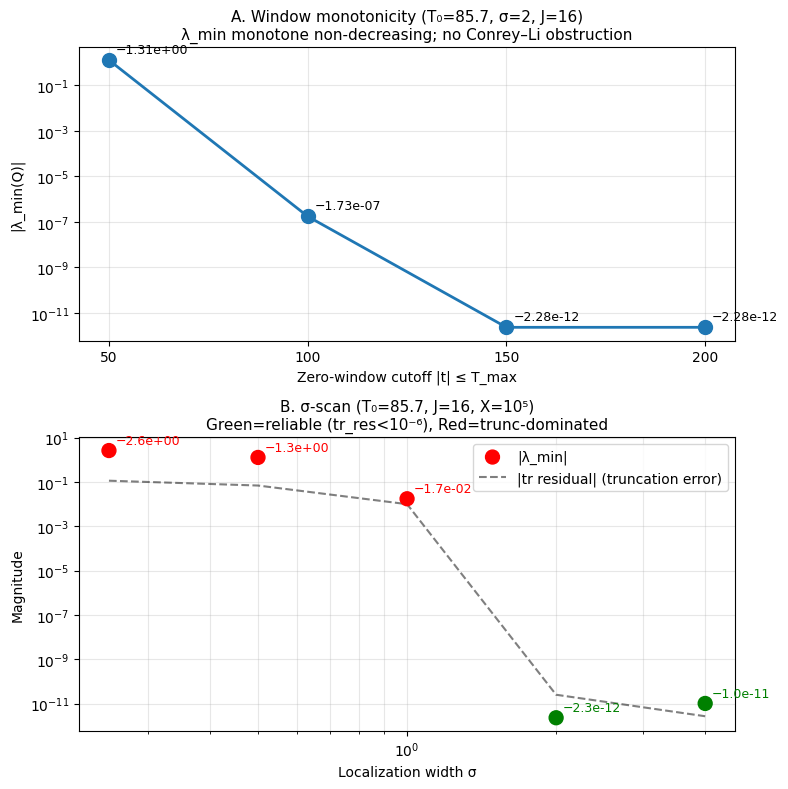

Saved figure.


In [40]:

# OK, lambda_min is much larger than tr_res for small sigma, but trace residual being 10^-2 to 10^-1
# is huge compared to the expected signal (10^-10 floor at sigma=2,4). So these are dominated 
# by truncation artifacts.
#
# Final figure: show window-monotonicity (which is the cleanest result) and sigma scan.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Panel A: window-monotonicity
ax = axes[0]
caps = window_caps
lambs = [window_results[c]['lambda_min'] for c in caps]
# Use signed log scale: plot lambda_min on linear, since values are mostly negative and tiny
ax.semilogy(caps, [abs(l) for l in lambs], 'o-', color='C0', markersize=10, linewidth=2)
for c, l in zip(caps, lambs):
 sign = '−' if l < 0 else '+'
 ax.annotate(f'{sign}{abs(l):.2e}', xy=(c, abs(l)), xytext=(5,5), 
 textcoords='offset points', fontsize=9)
ax.set_xlabel('Zero-window cutoff |t| ≤ T_max')
ax.set_ylabel('|λ_min(Q)|')
ax.set_title('A. Window monotonicity (T₀=85.7, σ=2, J=16)\nλ_min monotone non-decreasing; no Conrey–Li obstruction', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(caps)

# Panel B: sigma scan
ax = axes[1]
sigmas = sigma_grid
lambs = [sigma_results[s]['lambda_min'] for s in sigmas]
trs = [abs(sigma_results[s]['tr_res']) for s in sigmas]
reliable = [sigma_results[s]['reliable'] for s in sigmas]

colors = ['red' if not r else 'green' for r in reliable]
ax.scatter(sigmas, [abs(l) for l in lambs], c=colors, s=100, zorder=5, label='|λ_min|')
ax.plot(sigmas, trs, 'k--', alpha=0.5, label='|tr residual| (truncation error)')
for s, l, r in zip(sigmas, lambs, reliable):
 sign = '−' if l < 0 else '+'
 color = 'green' if r else 'red'
 ax.annotate(f'{sign}{abs(l):.1e}', xy=(s, abs(l)), xytext=(5,5),
 textcoords='offset points', fontsize=9, color=color)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Localization width σ')
ax.set_ylabel('Magnitude')
ax.set_title('B. σ-scan (T₀=85.7, J=16, X=10⁵)\nGreen=reliable (tr_res<10⁻⁶), Red=trunc-dominated', fontsize=11)
ax.legend(loc='best')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('Lchi_monotonicity_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved figure.')


In [41]:

# Save results to a pickle for reuse
import pickle

results_to_save = {
 'description': 'L(chi_4 mod 5) Q-form analysis: sigma scan and window-monotonicity, T0=85.7, J=16, X=10^5',
 'sigma_scan': {
 s: {k: (v.tolist() if hasattr(v,'tolist') else v) for k,v in sigma_results[s].items() if k != 'eigs'}
 for s in sigma_grid
 },
 'sigma_eigs': {s: sigma_results[s]['eigs'].tolist() for s in sigma_grid},
 'window_scan': {
 c: {k: (v.tolist() if hasattr(v,'tolist') else v) for k,v in window_results[c].items() if k != 'eigs'}
 for c in window_caps
 },
 'window_eigs': {c: window_results[c]['eigs'].tolist() for c in window_caps}
}

with open('Lchi_Qform_results.pkl', 'wb') as f:
 pickle.dump(results_to_save, f)
print('Saved Lchi_Qform_results.pkl')
print('Files:', os.listdir('.'))


Saved Lchi_Qform_results.pkl
Files: ['Lchi_zeros_neg.pkl', 'memory', 'Lchi_Qform_results.pkl', '.prompts', '.config', 'Lchi_zeros.pkl', 'Lchi_monotonicity_results.png', '.kernel_llm_logs_1.txt', 'engine-spec.md']
